In [2]:
import prism
from pathlib import Path
from imagematerials.factory import ModelFactory, Sector
from imagematerials.maintenance import Maintenance, MaintenanceLinear
from imagematerials.concepts import knowledge_graph
from plotting import material_colors, maintenance_types, type_colors
import matplotlib.pyplot as plt
import pickle as pkl
import os

from imagematerials.model import (
    GenericMaterials,
    GenericStocks
)
import warnings
from imagematerials.preprocessing import get_preprocessing_data

In [59]:
scenario_colors = {
        'standard_constant': '#1f77b4',  # blue
        'standard_linear': '#ff7f0e',    # orange
        'slow_constant': '#2ca02c',      # green
        'slow_linear': '#d62728'         # red
    }

# Scenario Settings

In [4]:
# Define simulation parameters
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1920, 2100, 1)

scenario_list = {
    'standard_linear': {
        'label': 'Standard Lifetimes & Linear Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'linear'
    },
    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
    'slow_linear': {
        'label': 'Slow Lifetimes & Linear Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear'
    }
}

scenario_list2 = {

    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
}

In [5]:
base_dir = Path("..", "..", "image-materials", "data", "raw")
circular_economy_scenario_dirs = {
        "base": base_dir / 'circular_economy_scenarios' / 'base'
    }
climate_policy_scenario_dir = base_dir /'SSP2'

vhc_sector = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir, circular_economy_scenario_dirs,cache = "vhc_sector3.nc")

circular_economy_scenario_dirs_slow = {
        "slow": base_dir / 'circular_economy_scenarios' / 'slow'
    }
climate_policy_scenario_dir_slow = base_dir /  'SSP2'

vhc_sector_slow = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir_slow, circular_economy_scenario_dirs_slow, cache = "vhc_sector_slow3.nc")


In [6]:
all_output = {}

for scen_id, scenario_config in scenario_list.items():   
    pkl_path = f"{scen_id}.pkl"
    if not os.path.exists(pkl_path):
        print(f"\n=== Running Scenario: {scen_id} ===")
        
        # Select the appropriate sector data based on circular economy scenario
        if scenario_config['circular_scen'] == 'standard':
            sector_data = vhc_sector
            print("Using standard sector data")
        elif scenario_config['circular_scen'] == 'slow':
            sector_data = vhc_sector_slow
            print("Using slow circular economy sector data")

        sector_data.all_data["cap_at_lifetime"]=False
        
        # Create factory with appropriate sector data
        factory = ModelFactory(
            sector_data, complete_timeline
        ).add(GenericStocks
        ).add(GenericMaterials)
        
        # Add the appropriate maintenance model based on maintenance scenario
        if scenario_config['maintenance_scen'] == 'constant':
            factory = factory.add(Maintenance)
            print("Using constant maintenance model")
        elif scenario_config['maintenance_scen'] == 'linear':
            # Pass vehicle_lifetimes as an explicit parameter to MaintenanceLinear
            factory = factory.add(MaintenanceLinear)
            print("Using linear maintenance model with explicit vehicle lifetimes")
        
        # Finish model creation
        model = factory.finish()
        
        # Run simulation
        
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            model.simulate(simulation_timeline)
        
        # Store results
        all_output[scen_id] = {
            'model': model,
            'inflow_maintenance': model.inflow_maintenance.to_array(),
            'circular_scenario': scenario_config['circular_scen'],
            'maintenance_scenario': scenario_config['maintenance_scen'],
            'label': scenario_config['label']
        }
        
        print(f"✓ Completed: {scen_id}")
        all_output[scen_id]["model"].save_pkl(pkl_path)
        print(f"\n=== All {len(all_output)} scenarios completed successfully ===")
    else:
        with open(pkl_path, "rb") as handle:
            model = pkl.load(handle)

                # Store results in the same format as when we calculate it
        all_output[scen_id] = {
            'model': model['vehicles'],
            'inflow_maintenance': model['vehicles']['inflow_maintenance'].to_array(),
            'circular_scenario': scenario_config['circular_scen'],
            'maintenance_scenario': scenario_config['maintenance_scen'],
            'label': scenario_config['label']
        }
        print(f"✓ Loaded: {scen_id}")


print("Available scenarios:", list(all_output.keys()))


✓ Loaded: standard_linear
✓ Loaded: standard_constant
✓ Loaded: slow_constant
✓ Loaded: slow_linear
Available scenarios: ['standard_linear', 'standard_constant', 'slow_constant', 'slow_linear']


# Figure 5: Scenario results


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\5982758\AppData\Local\Temp\ipykernel_39512\2643732723.py:78: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\5982758\AppData\Local\Temp\ipykernel_39512\2643732723.py:78: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3

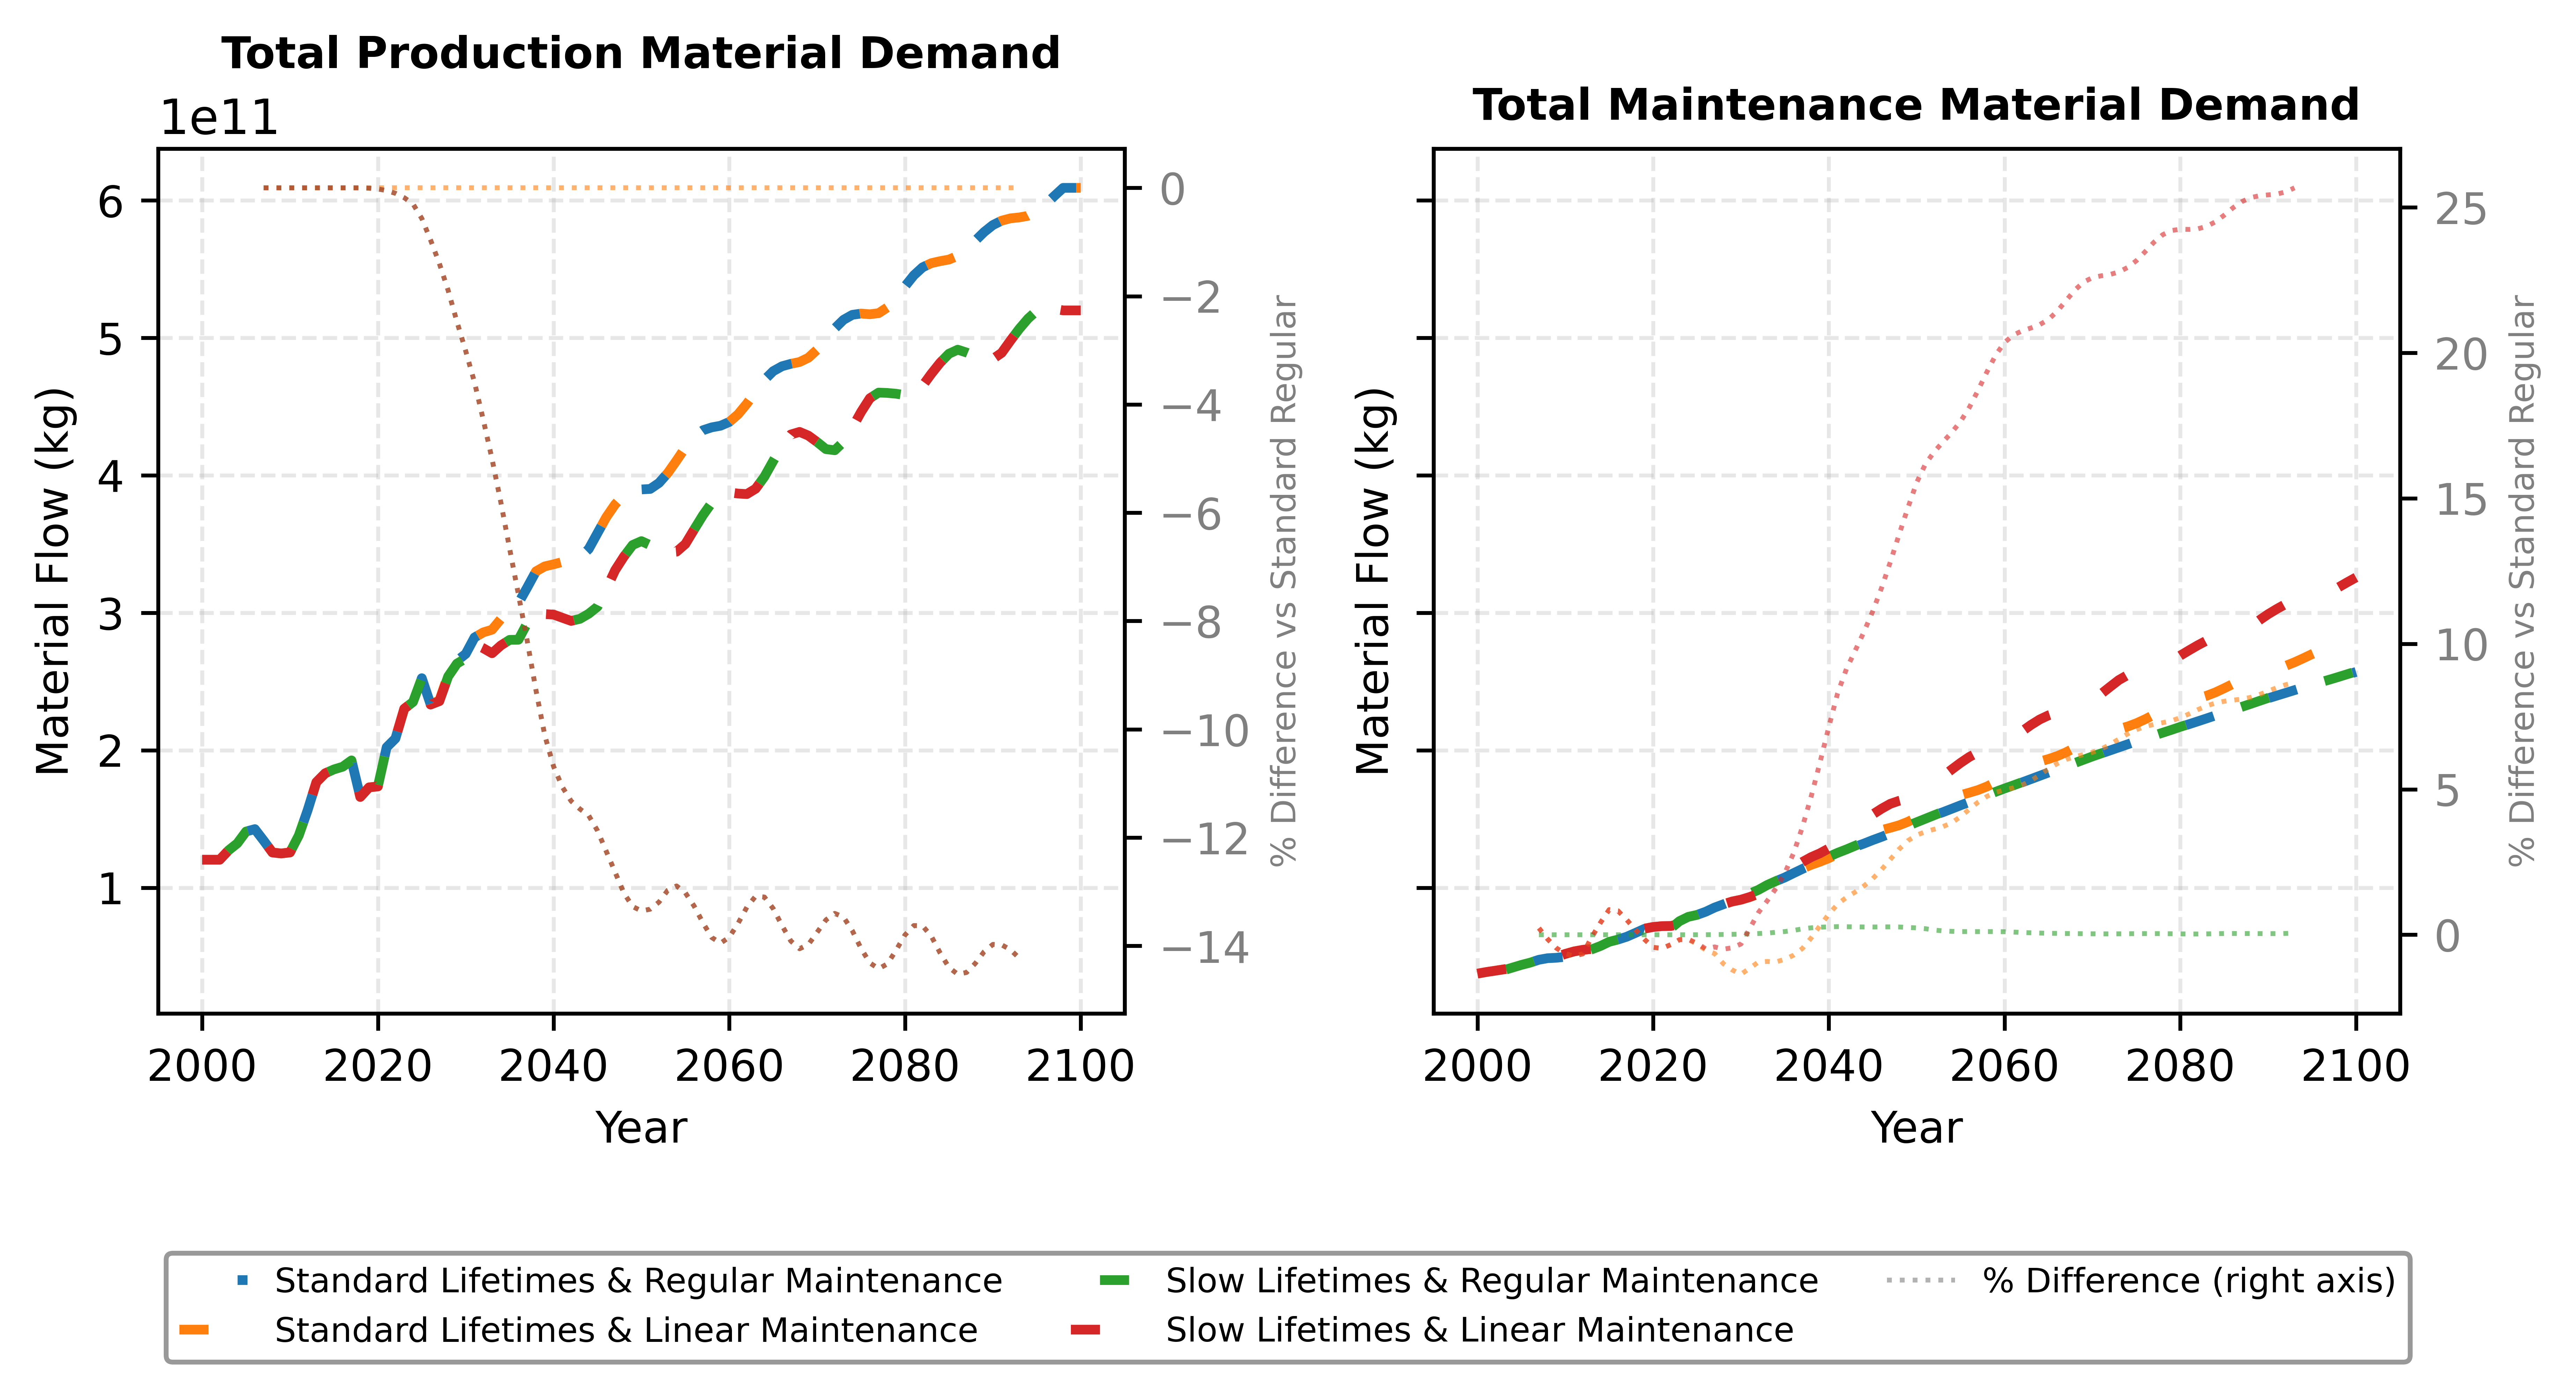

In [65]:
"""
Create side-by-side plots comparing total maintenance and production material demand across scenarios
with improved visibility and comparable scales, plus percentage differences on right y-axis.
"""
year_range=(2000, 2100)
scenarios = list(all_output.keys())

line_styles = {
    'standard_constant': (3, (3, 6)),            # dashed with offset 0
    'standard_linear': (0, (3, 6)),              # same dash pattern but offset by 1
    'slow_constant': (6, (3, 6)),                # same dash pattern but offset by 2
    'slow_linear': (0, (3, 6)),                   # same dash pattern but offset by 3
}

dot_styles = {
    'standard_constant': (1, (1, 3)),            # dashed with offset 0
    'standard_linear': (0, (1, 3)),              # same dash pattern but offset by 1
    'slow_constant': (2, (1, 3)),                # same dash pattern but offset by 2
    'slow_linear': (0, (1, 3)),                   # same dash pattern but offset by 3
}

width_mm = 190
width_inches = width_mm / 25.4  # Convert mm to inches
aspect_ratio = 1/2  
height_inches = width_inches * aspect_ratio

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width_inches, height_inches), sharey=True, dpi=1000)

max_value = 0  # Track maximum value for scaling
scenario_data = {}

# Store time series data for percentage calculations
scenario_timeseries = {}

# Process each scenario
for scenario in scenarios:
    if scenario not in all_output:
        print(f"Warning: Scenario {scenario} not found!")
        continue
    
    # Get scenario label, color and line style
    label = all_output[scenario]['label']
    color = scenario_colors.get(scenario, '#999999')
    linestyle = line_styles.get(scenario, (0, (5, 2)))
    
    # --- MAINTENANCE PLOT (Left) ---
    maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
    maint_df = maint_array.to_pandas()
    maint_df_full = maint_df[(maint_df.index >= year_range[0]) & (maint_df.index <= year_range[1])]
    
    # Store for percentage calculations
    scenario_timeseries[scenario] = {
        'maintenance': maint_df_full,
    }
    
    # Update max value
    max_value = max(max_value, maint_df_full.max())
    
    # Calculate total maintenance sum for this scenario
    maint_sum = maint_df[(maint_df.index >= 2025) & (maint_df.index <= year_range[1])].sum()
    
    # Plot with offset dashed lines
    ax2.plot(maint_df_full.index, maint_df_full, 
                label=label, 
                color=color,
                linestyle=linestyle,
                linewidth=2)
    
    # --- PRODUCTION PLOT (Right) ---
    prod_array = all_output[scenario]['model']["inflow_materials"].to_array().sum(dim=['Region', 'material'])
    prod_array = knowledge_graph.aggregate_sum(prod_array, output_coords=maintenance_types, dim="Type").sum(dim=['Type'])
    prod_df = prod_array.to_pandas()
    prod_df_full = prod_df[(prod_df.index >= year_range[0]) & (prod_df.index <= year_range[1])]
    
    # Apply rolling mean to smooth production data
    prod_df_full = prod_df_full.rolling(window=5, center=True).mean()
    prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window
    
    # Store for percentage calculations
    scenario_timeseries[scenario]['production'] = prod_df_full
    
    # Calculate total production sum for this scenario
    prod_sum = prod_df[(prod_df.index >= 2025) & (prod_df.index <= year_range[1])].sum()
    
    # Update max value from production too
    max_value = max(max_value, prod_df_full.max())
    
    # Plot with offset dashed lines
    ax1.plot(prod_df_full.index, prod_df_full, 
                label=label, 
                color=color,
                linestyle=linestyle,
                linewidth=2)
    
    # Store data for later use in annotations
    scenario_data[scenario] = {
        'maintenance_total': maint_sum,
        'production_total': prod_sum,
        'label': label
    }

# Create secondary y-axes for percentage differences
ax1_pct = ax1.twinx()
ax2_pct = ax2.twinx()

# Calculate and plot percentage differences (using standard_constant as baseline)
if 'standard_constant' in scenario_timeseries:
    baseline_maint = scenario_timeseries['standard_constant']['maintenance']
    baseline_prod = scenario_timeseries['standard_constant']['production']
    
    # Plot percentage differences for maintenance
    for scenario in scenarios:
        if scenario != 'standard_constant' and scenario in scenario_timeseries:
            color = scenario_colors.get(scenario, '#999999')
            dotstyle = dot_styles.get(scenario, (0, (5, 2)))
            
            # Maintenance percentage difference
            maint_pct_diff = ((scenario_timeseries[scenario]['maintenance'] - baseline_maint) / baseline_maint * 100)
            maint_pct_diff = maint_pct_diff.rolling(window=15, center=True).mean()
            ax2_pct.plot(maint_pct_diff.index, maint_pct_diff, 
                        color=color, alpha=0.6, linewidth=1, linestyle=':')
            
            # Production percentage difference
            prod_pct_diff = ((scenario_timeseries[scenario]['production'] - baseline_prod) / baseline_prod * 100)
            prod_pct_diff = prod_pct_diff.rolling(window=15, center=True).mean()
            ax1_pct.plot(prod_pct_diff.index, prod_pct_diff, 
                        color=color, alpha=0.6, linewidth=1, linestyle=':')

# Style the percentage axes
ax2_pct.set_ylabel('% Difference vs Standard Regular', fontsize=7, color='gray')
ax2_pct.tick_params(axis='y', labelcolor='gray', labelsize=9)
ax2_pct.grid(False)  # Don't interfere with main grid

ax1_pct.set_ylabel('% Difference vs Standard Regular', fontsize=7, color='gray')
ax1_pct.tick_params(axis='y', labelcolor='gray', labelsize=9)
ax1_pct.grid(False)  # Don't interfere with main grid

# Add horizontal line at 0% for reference
#ax1_pct.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
#ax2_pct.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Add grid for easier reading of values
ax1.grid(True, linestyle='--', alpha=0.3)
ax2.grid(True, linestyle='--', alpha=0.3)

# --- Style the plots ---
ax2.set_title('Total Maintenance Material Demand', fontsize=9, fontweight='bold')
ax2.set_xlabel('Year', fontsize=9)
ax2.set_ylabel('Material Flow (kg)', fontsize=9)
ax2.tick_params(labelsize=9)


ax1.set_title('Total Production Material Demand', fontsize=9, fontweight='bold')
ax1.set_xlabel('Year', fontsize=9)
ax1.set_ylabel('Material Flow (kg)', fontsize=9)
ax1.tick_params(labelsize=9)

# Add annotations with statistics in the corners
if 'standard_constant' in scenario_data:
    base_maint = scenario_data['standard_constant']['maintenance_total']
    base_prod = scenario_data['standard_constant']['production_total']
    
    # Top left corner of maintenance plot - Compare linear to constant maintenance
    annotation_text = "Maintenance Increase vs Standard Regular 2025 to 2100:\n"
    
    if 'standard_linear' in scenario_data:
        sl_maint = scenario_data['standard_linear']['maintenance_total']
        diff = sl_maint - base_maint
        pct = (diff / base_maint) * 100
        annotation_text += f"• Standard Linear: +{pct:.1f}% ({diff:.2e} kg)\n"
    
    if 'slow_linear' in scenario_data:
        sl_maint = scenario_data['slow_linear']['maintenance_total']
        diff = sl_maint - base_maint
        pct = (diff / base_maint) * 100
        annotation_text += f"• Slow Linear: +{pct:.1f}% ({diff:.2e} kg)"
        
    #ax2.text(0.05, 0.95, annotation_text,
    #            transform=ax2.transAxes,
    #            fontsize=10,
    #            verticalalignment='top',
    #            horizontalalignment='left',
    #            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
    
    # Bottom right corner of production plot - Compare slow linear to standard constant
    if 'slow_linear' in scenario_data:
        sl_prod = scenario_data['slow_linear']['production_total']
        prod_diff = sl_prod - base_prod
        prod_pct = (prod_diff / base_prod) * 100
        
        prod_annotation = f"Extended lifetimes (slow) versus regular lifetimes 2025 to 2100:\n"
        prod_annotation += f"Production: {prod_pct:.1f}% ({prod_diff:.2e} kg)"
        
        #ax1.text(0.95, 0.2, prod_annotation,
        #            transform=ax1.transAxes,
        #            fontsize=10,
        #            verticalalignment='bottom',
        #            horizontalalignment='right',
        #            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))

# Create single legend for both plots with custom order
handles, labels = ax1.get_legend_handles_labels()

# Define the desired order for scenarios
desired_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

# Create ordered handles and labels
ordered_handles = []
ordered_labels = []

for scenario in desired_order:
    if scenario in scenarios:
        # Find the index of this scenario in the original lists
        scenario_label = all_output[scenario]['label']
        if scenario_label in labels:
            idx = labels.index(scenario_label)
            ordered_handles.append(handles[idx])
            ordered_labels.append(labels[idx])

# Add explanation for dotted lines in legend
import matplotlib.lines as mlines
pct_line = mlines.Line2D([], [], color='gray', linestyle=':', linewidth=1, alpha=0.6, label='% Difference of 10 year average (right axis)')
ordered_handles.append(pct_line)
ordered_labels.append('% Difference (right axis)')

legend = fig.legend(ordered_handles, ordered_labels, 
                   loc='lower center', 
                   bbox_to_anchor=(0.5, -0.07),
                   ncol=3,  
                   fontsize=7,
                   frameon=True,
                   fancybox=True,
                   shadow=False,
                   edgecolor='gray',
                   facecolor='white')

# Adjust layout
plt.tight_layout()  # Make room for legend at bottom
plt.subplots_adjust(bottom=0.21)
plt.savefig('Figure5_1.png', dpi=1000, bbox_inches='tight')
plt.show()



In [17]:
#all_output['standard_constant']['model'].stocks
import pandas as pd
import numpy as np

comparison_types = ["Cars","Trucks","Buses","Trains","Ships","Passenger Planes","Bikes"]


old_stock = pd.read_csv("VEMA_vehicle_stock.csv", index_col=0).T
old_stock.index = old_stock.index.astype(int)
old_stock = old_stock.rename(columns={'Planes': 'Passenger Planes','Bicycles': 'Bikes'})

new_stock_all = all_output["slow_constant"]["model"].stock_by_cohort_materials.sum(dim=["Region","material"])
new_stock_df = knowledge_graph.aggregate_sum(new_stock_all, output_coords=comparison_types, dim="Type").to_pandas().T

start_year = 2000
end_year = 2060

old_stock_filtered = old_stock.loc[start_year:end_year] 
new_stock_filtered = new_stock_df.loc[start_year:end_year] 

common_columns = [col for col in comparison_types if col in old_stock_filtered.columns]
old_stock_filtered = old_stock_filtered[common_columns]
new_stock_filtered = new_stock_filtered[common_columns]

fig, axs = plt.subplots(len(comparison_types), 1, figsize=(12, 3*len(comparison_types)), sharex=True)

for i, vehicle_type in enumerate(comparison_types):
    ax = axs[i]
    
    # Plot old stock if the vehicle type exists in old_stock
    if vehicle_type in old_stock_filtered.columns:
        ax.plot(old_stock_filtered.index, old_stock_filtered[vehicle_type], 
                'b-', label='VEMA Model', linewidth=2)
    
    # Plot new stock
    ax.plot(new_stock_filtered.index, new_stock_filtered[vehicle_type], 
            'r--', label='New Model', linewidth=2)
    
    ax.set_title(f'{vehicle_type} Stock Comparison')
    ax.set_ylabel("Total Vehicle Weight (kg)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Calculate percentage differences and create a summary table
print("\nComparison between VEMA and New Model:")
print("="*70)
print(f"{'Year':<8}{'Vehicle Type':<15}{'VEMA Model':<15}{'New Model':<15}{'Difference':<12}{'% Diff':<10}")
print("-"*70)

sample_years = [2000, 2020,2040,  2060]
sample_years = [y for y in sample_years if y in old_stock_filtered.index and y in new_stock_filtered.index]

for year in sample_years:
    for vehicle_type in comparison_types:
        if vehicle_type in old_stock_filtered.columns:
            old_val = old_stock_filtered.loc[year, vehicle_type] if year in old_stock_filtered.index else np.nan
            new_val = new_stock_filtered.loc[year, vehicle_type] if year in new_stock_filtered.index else np.nan
            
            if not np.isnan(old_val) and not np.isnan(new_val):
                diff = new_val - old_val
                pct_diff = (diff / old_val) * 100 if old_val != 0 else np.nan
                
                print(f"{year:<8}{vehicle_type:<15}{old_val:<15.2e}{new_val:<15.2e}{diff:<12.2e}{pct_diff:<10.1f}%")
    
    print("-"*70)

# 6. Plot total vehicle stock comparison
old_total = old_stock_filtered.sum(axis=1) if not old_stock_filtered.empty else pd.Series()
new_total = new_stock_filtered.sum(axis=1)

plt.figure(figsize=(12, 6))
if not old_total.empty:
    plt.plot(old_total.index, old_total, 'b-', label='VEMA Total', linewidth=2)
plt.plot(new_total.index, new_total, 'r--', label='New Model Total', linewidth=2)

plt.title('Total Vehicle Stock Comparison', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel("Total Vehicle Weight (kg)", fontsize=12)
ax.set_yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


AttributeError: 'dict' object has no attribute 'stock_by_cohort_materials'

In [ ]:
old_stock = pd.read_csv("VEMA_vehicle_stock.csv", index_col=0).T
old_stock.index = old_stock.index.astype(int)
old_stock

elements,Bicycles,Cars,Planes,Trains,Buses,Rail Cargo,Air Cargo,Trucks,Ships
2000,2.318354e+10,8.255608e+11,4.497906e+08,1.264784e+10,1.089315e+11,1.279118e+11,3.387493e+08,2.664625e+11,1.636799e+11
2001,2.330765e+10,8.570656e+11,4.477488e+08,1.282451e+10,1.121979e+11,1.264213e+11,3.431265e+08,2.645896e+11,1.635553e+11
2002,2.340136e+10,8.757858e+11,4.470347e+08,1.312236e+10,1.159008e+11,1.257124e+11,3.479829e+08,2.695443e+11,1.639970e+11
2003,2.361490e+10,8.997808e+11,4.481335e+08,1.319749e+10,1.183006e+11,1.264552e+11,3.542867e+08,2.801231e+11,1.669079e+11
2004,2.366055e+10,9.334327e+11,5.097392e+08,1.359443e+10,1.225226e+11,1.287601e+11,4.026447e+08,3.008997e+11,1.725388e+11
...,...,...,...,...,...,...,...,...,...
2056,2.308415e+10,1.495260e+12,5.212068e+08,7.208124e+10,1.840018e+11,2.944330e+11,7.458036e+08,1.007402e+12,2.526522e+11
2057,2.296026e+10,1.500136e+12,5.163733e+08,7.466633e+10,1.837110e+11,2.963891e+11,7.422651e+08,1.014088e+12,2.536330e+11
2058,2.282629e+10,1.504976e+12,5.119163e+08,7.707733e+10,1.833281e+11,2.983349e+11,7.389851e+08,1.021101e+12,2.546752e+11
2059,2.268458e+10,1.510093e+12,5.079751e+08,7.928641e+10,1.828468e+11,3.003185e+11,7.360363e+08,1.028416e+12,2.557812e+11


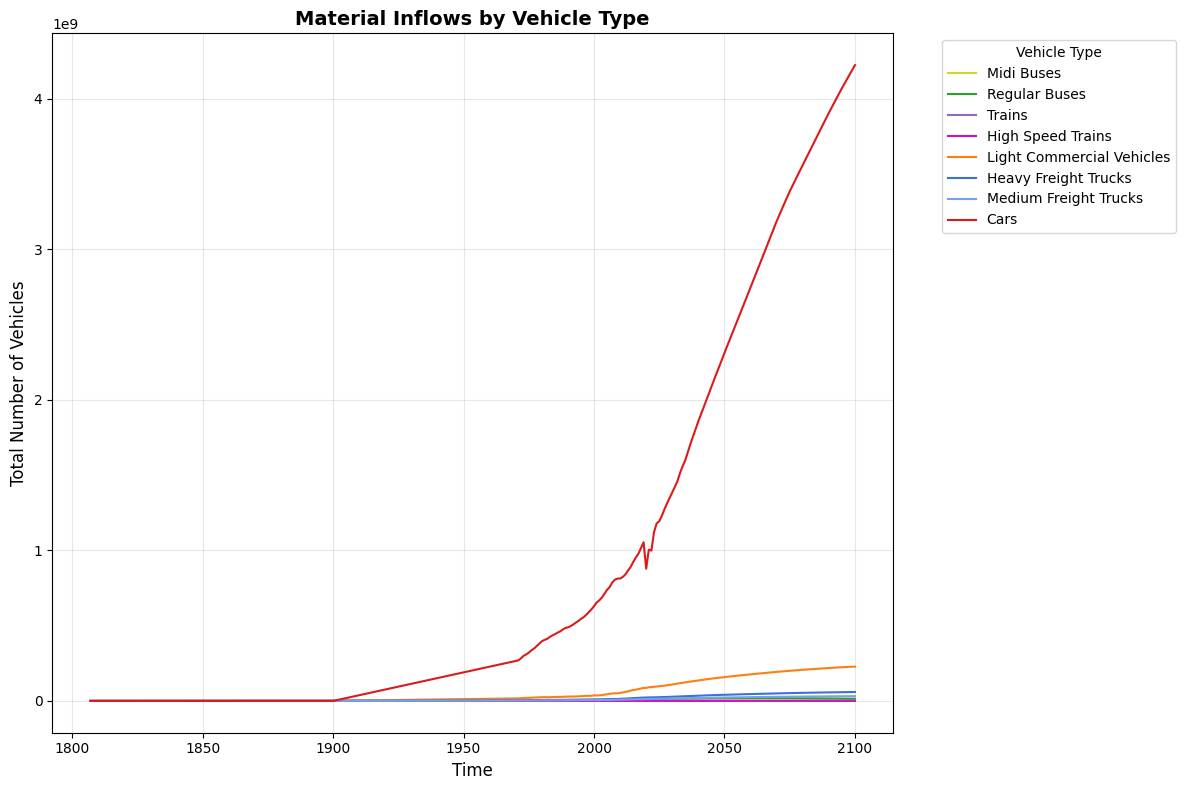

In [ ]:
types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Heavy Freight Trucks", "Medium Freight Trucks",
    "Cars"
]

materials = all_output["standard_constant"]["model"].stocks.sum(dim=["Region"])
rebroadcast_materials = knowledge_graph.aggregate_sum(materials, output_coords=types, dim="Type")


# Create a figure first
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each vehicle type separately with explicit dimensions
for vehicle_type in rebroadcast_materials.coords["Type"].values:
    color = type_colors.get(vehicle_type, '#333333')  # Default to dark gray if not found
    data_for_type = rebroadcast_materials.sel(Type=vehicle_type)
    data_for_type.plot.line(ax=ax, label=vehicle_type, color=color)

# Customize plot appearance
ax.set_title('Material Inflows by Vehicle Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Total Number of Vehicles', fontsize=12)
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


AttributeError: 'dict' object has no attribute 'inflow_materials'

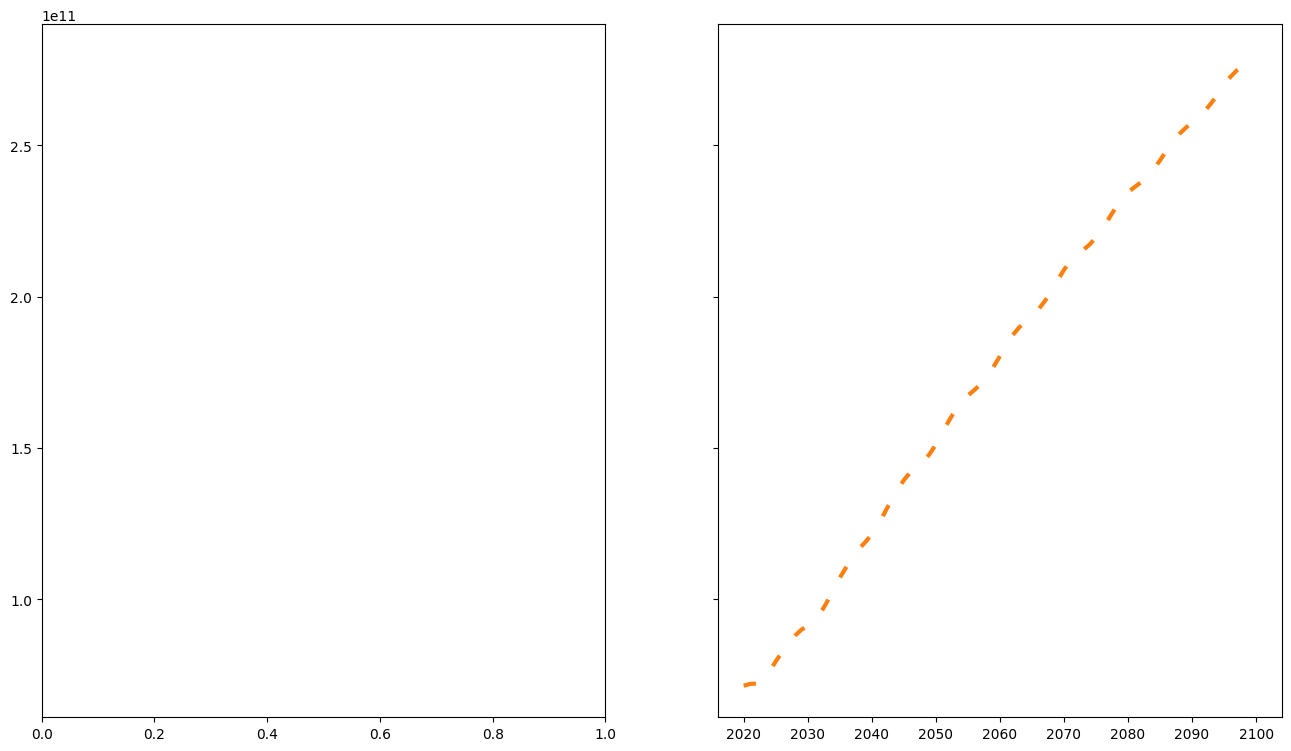

In [ ]:
def plot_maintenance_production_comparison(all_output, scenario_colors,year_range=(2020, 2100),  scenarios=None):
    """
    Create side-by-side plots comparing total maintenance and production material demand across scenarios
    with improved visibility and comparable scales.
    """
    if scenarios is None:
        scenarios = list(all_output.keys())
    
    line_styles = {
        'standard_constant': (3, (3, 6)),            # dashed with offset 0
        'standard_linear': (0, (3, 6)),              # same dash pattern but offset by 1
        'slow_constant': (6, (3, 6)),                # same dash pattern but offset by 2
        'slow_linear': (0, (3, 6)),                   # same dash pattern but offset by 3
    }
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), sharey=True)  # Set sharey=True for same y-scale
    
    max_value = 0  # Track maximum value for scaling

        # Calculate sums for the entire period and store data for each scenario
    scenario_data = {}
    
    # Process each scenario
    for scenario in scenarios:
        if scenario not in all_output:
            print(f"Warning: Scenario {scenario} not found!")
            continue
        
        # Get scenario label, color and line style
        label = all_output[scenario]['label']
        color = scenario_colors.get(scenario, '#999999')
        linestyle = line_styles.get(scenario, (0, (5, 2)))
        
        # --- MAINTENANCE PLOT (Left) ---
        maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_df_full = maint_df[(maint_df.index >= year_range[0]) & (maint_df.index <= year_range[1])]
        
        # Update max value
        max_value = max(max_value, maint_df_full.max())
        
        # Calculate total maintenance sum for this scenario
        maint_sum = maint_df[(maint_df.index >= 2025) & (maint_df.index <= year_range[1])].sum()
        
        # Plot with offset dashed lines
        ax2.plot(maint_df_full.index, maint_df_full, 
                 label=label, 
                 color=color,
                 linestyle=linestyle,
                 linewidth=3)
        
        # --- PRODUCTION PLOT (Right) ---
        prod_array = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region', 'material'])
        prod_array = knowledge_graph.aggregate_sum(prod_array, output_coords=maintenance_types, dim="Type").sum(dim=[ 'Type'])
        prod_df = prod_array.to_pandas()
        prod_df_full = prod_df[(prod_df.index >= year_range[0]) & (prod_df.index <= year_range[1])]
        
        # Apply rolling mean to smooth production data
        prod_df_full = prod_df_full.rolling(window=5, center=True).mean()
        prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window
        
        # Calculate total production sum for this scenario
        prod_sum = prod_df[(prod_df.index >= 2025) & (prod_df.index <= year_range[1])].sum()
        
        # Update max value from production too
        max_value = max(max_value, prod_df_full.max())
        
        # Plot with offset dashed lines
        ax1.plot(prod_df_full.index, prod_df_full, 
                 label=label, 
                 color=color,
                 linestyle=linestyle,
                 linewidth=3)
        
        # Store data for later use in annotations
        scenario_data[scenario] = {
            'maintenance_total': maint_sum,
            'production_total': prod_sum,
            'label': label
        }
    

    
    
    # Add grid for easier reading of values
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # --- Style the plots ---
    ax2.set_title('Total Maintenance Material Demand', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=14)
    ax2.set_ylabel('Material Flow (kg)', fontsize=14)
    ax2.tick_params(labelsize=12)
    
    ax1.set_title('Total Production Material Demand', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Year', fontsize=14)
    ax1.set_ylabel('Material Flow (kg)', fontsize=14)
    ax1.tick_params(labelsize=12)

    # Add annotations with statistics in the corners
    if 'standard_constant' in scenario_data:
        base_maint = scenario_data['standard_constant']['maintenance_total']
        base_prod = scenario_data['standard_constant']['production_total']
        
        # Top left corner of maintenance plot - Compare linear to constant maintenance
        annotation_text = "Maintenance Increase vs Standard Regular 2025 to 2100:\n"
        
        if 'standard_linear' in scenario_data:
            sl_maint = scenario_data['standard_linear']['maintenance_total']
            diff = sl_maint - base_maint
            pct = (diff / base_maint) * 100
            annotation_text += f"• Standard Linear: +{pct:.1f}% ({diff:.2e} kg)\n"
        
        if 'slow_linear' in scenario_data:
            sl_maint = scenario_data['slow_linear']['maintenance_total']
            diff = sl_maint - base_maint
            pct = (diff / base_maint) * 100
            annotation_text += f"• Slow Linear: +{pct:.1f}% ({diff:.2e} kg)"
            
        ax2.text(0.05, 0.95, annotation_text,
                 transform=ax1.transAxes,
                 fontsize=12,
                 verticalalignment='top',
                 horizontalalignment='left',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
        
        # Bottom right corner of production plot - Compare slow linear to standard constant
        if 'slow_linear' in scenario_data:
            sl_prod = scenario_data['slow_linear']['production_total']
            prod_diff = sl_prod - base_prod
            prod_pct = (prod_diff / base_prod) * 100
            
            prod_annotation = f"Extended lifetimes (slow) versus regular lifetimes 2025 to 2100:\n"
            prod_annotation += f"Production: {prod_pct:.1f}% ({prod_diff:.2e} kg)"
            
            ax1.text(0.95, 0.05, prod_annotation,
                     transform=ax2.transAxes,
                     fontsize=12,
                     verticalalignment='bottom',
                     horizontalalignment='right',
                     bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
    
    
    # Create single legend for both plots with custom order
    handles, labels = ax1.get_legend_handles_labels()

    # Define the desired order for scenarios
    desired_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

    # Create ordered handles and labels
    ordered_handles = []
    ordered_labels = []

    for scenario in desired_order:
        if scenario in scenarios:
            # Find the index of this scenario in the original lists
            scenario_label = all_output[scenario]['label']
            if scenario_label in labels:
                idx = labels.index(scenario_label)
                ordered_handles.append(handles[idx])
                ordered_labels.append(labels[idx])

    fig.legend(ordered_handles, ordered_labels, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 0.1),
            ncol=len(ordered_handles),
            fontsize=12)
    
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Make room for legend at bottom
    
    plt.show()

plot_maintenance_production_comparison(all_output, scenario_colors, year_range=(2020, 2100))


Processing scenario: standard_linear
maintenance - Data shape: (181, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (181, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: standard_constant


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (181, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: slow_constant
maintenance - Data shape: (181, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (181, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: slow_linear


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (181, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']


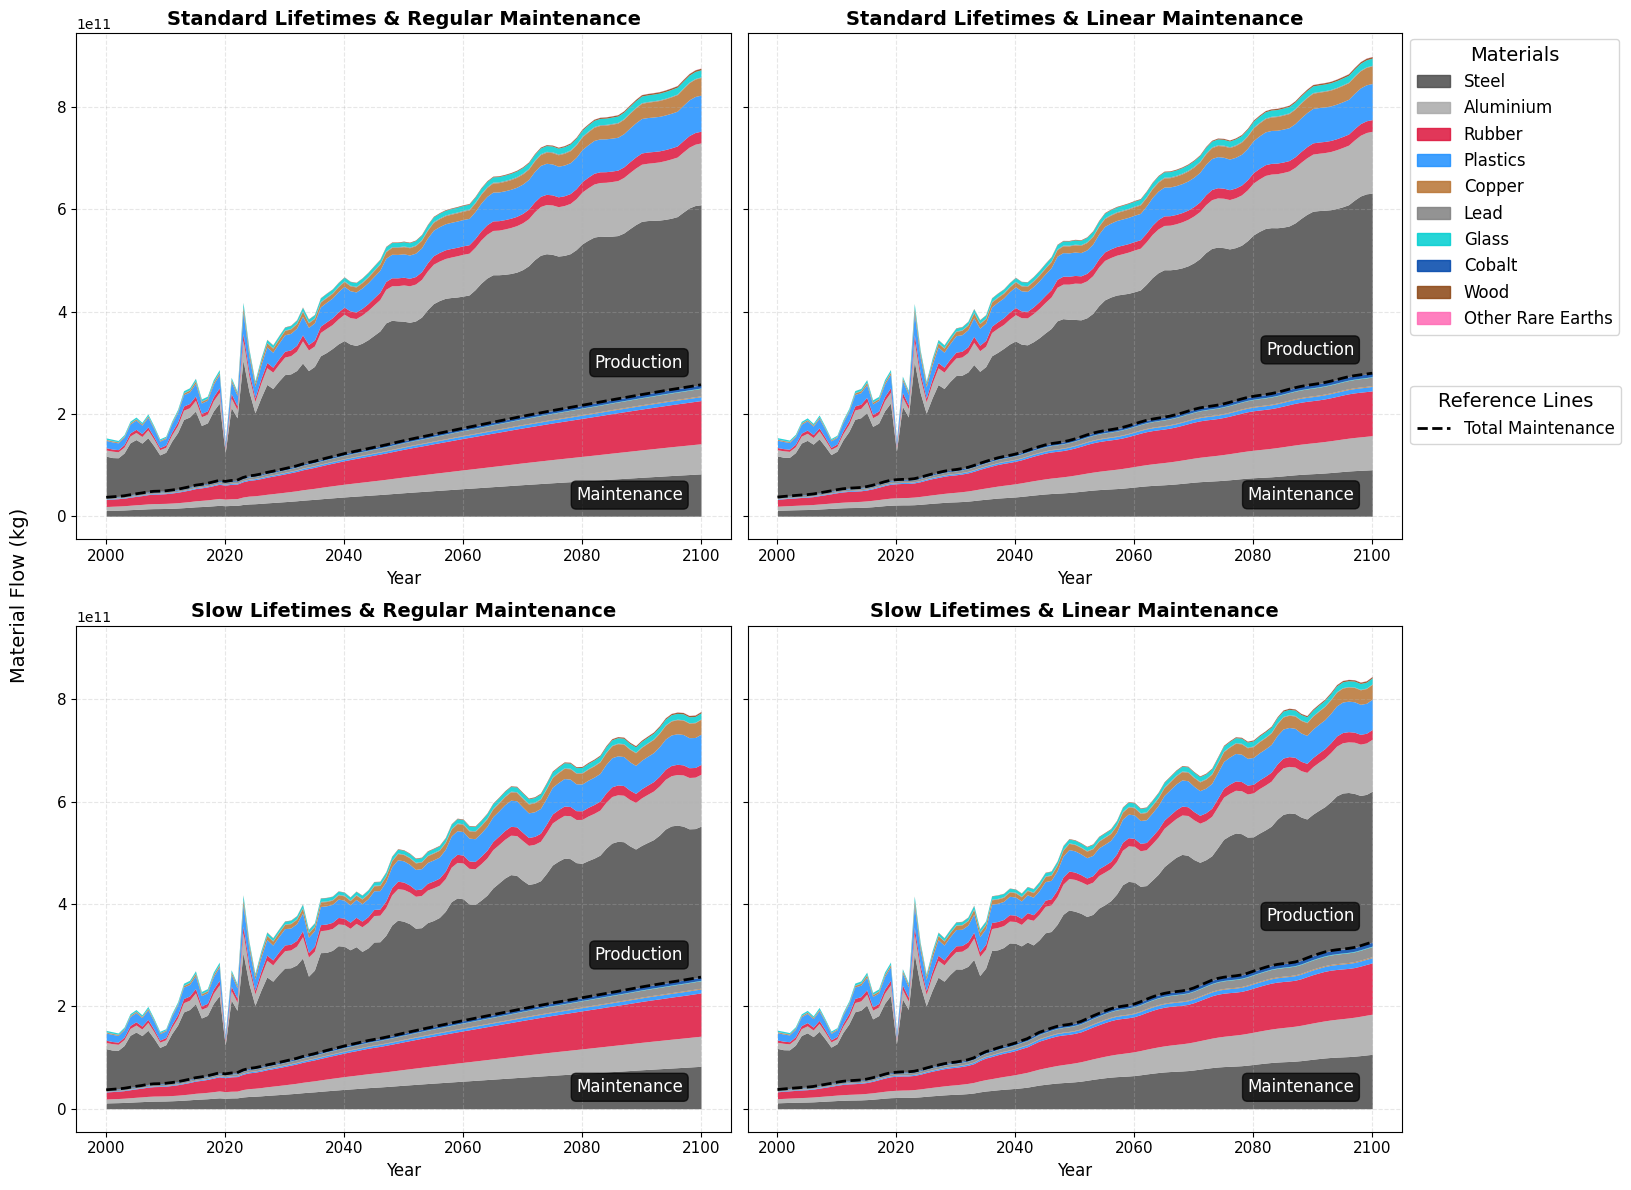

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph


"""
Create 2x2 subplot showing maintenance + production for all four scenarios
with materials stacked and uniform coloring across plots.
"""

# Define material colors (customize as needed)
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",  # will be removed after grouping
    "Cobalt": "#0047AB",  # cobalt blue
    "Other Rare Earths": "#FF69B4"  # pink
}

maintenance_types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Cars",
    "Medium Freight Trucks",
    "Heavy Freight Trucks",
]



# Helper function to process data for each scenario
def process_scenario_data(scenario_data):
    # Get maintenance and production data, sum over Region and Type
    maint_data = scenario_data['inflow_maintenance']
    prod_data = scenario_data["model"].inflow_materials.to_array()

    maint_data = knowledge_graph.aggregate_sum(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])
    prod_data = knowledge_graph.aggregate_sum(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])

        
    # Convert to pandas DataFrames
    maint_df = maint_data.to_pandas()
    prod_df = prod_data.to_pandas() 
    #prod_df = prod_df.rolling(window=10, center=True).mean()
    
    # Process both dataframes similarly
    for df, name in [(maint_df, 'maintenance'), (prod_df, 'production')]:
        if df is None:
            continue
            
        print(f"{name} - Data shape: {df.shape}")
        print(f"{name} - Data columns: {df.columns.tolist()}")
        
        # Group rare earth elements
        rare_earths = ["Nd", "Mn", "Ni", "Ti", "Li"]
        existing_rare_earths = [re for re in rare_earths if re in df.columns]
        if existing_rare_earths:
            df["Other Rare Earths"] = df[existing_rare_earths].sum(axis=1)
            df.drop(columns=existing_rare_earths, inplace=True, errors="ignore")
        
        # Rename materials for better display
        rename_map = {
            "Pb": "Lead",
            "Co": "Cobalt", 
            "Cu": "Copper",
            "Al": "Aluminum"
        }
        df.rename(columns=rename_map, inplace=True)
        
        # Filter from 2000 onwards
        df = df[df.index >= 2010]
        
        # Keep only non-zero materials
        valid_materials = (df != 0).any(axis=0)
        df = df.loc[:, valid_materials]
    
    # Update the original dataframes
    if prod_df is not None:
        # Ensure both have same columns for consistent plotting
        all_materials = set(maint_df.columns) | set(prod_df.columns)
        for mat in all_materials:
            if mat not in maint_df.columns:
                maint_df[mat] = 0
            if mat not in prod_df.columns:
                prod_df[mat] = 0
        
        # Sort columns by total sum (maintenance + production)
        total_materials = maint_df + prod_df
        sorted_cols = total_materials.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
        prod_df = prod_df[sorted_cols]
    else:
        # Sort maintenance only
        sorted_cols = maint_df.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
    
    return maint_df, prod_df

# Process all scenarios
processed_data = {}
for scen_id, scen_data in all_output.items():
    print(f"\nProcessing scenario: {scen_id}")
    maint_df, prod_df = process_scenario_data(scen_data)
    if not maint_df.empty:
        processed_data[scen_id] = {'maintenance': maint_df, 'production': prod_df}


# Get all unique materials across scenarios for consistent coloring
all_materials = set()
for scen_data in processed_data.values():
    all_materials.update(scen_data['maintenance'].columns)
    if scen_data['production'] is not None:
        all_materials.update(scen_data['production'].columns)

# Update material colors to include any missing materials
for material in all_materials:
    if material not in material_colors:
        material_colors[material] = '#999999'  # Default gray

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each scenario
scenario_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

for i, scen_id in enumerate(scenario_order):
    ax = axes[i]
    
    if scen_id not in processed_data:
        ax.text(0.5, 0.5, f"No data for\n{scen_id}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{scen_id} (No Data)", fontsize=14)
        continue
        
    maint_df = processed_data[scen_id]['maintenance']
    prod_df = processed_data[scen_id]['production']

   
    maint_df = maint_df[(maint_df.index >= 2000) & (maint_df.index <= 2100)]
    prod_df = prod_df[(prod_df.index >= 2000) & (prod_df.index <= 2100)]
    
    # Plot maintenance (bottom layer)
    colors_list = [material_colors.get(mat, '#999999') for mat in maint_df.columns]
    maint_df.plot.area(
        ax=ax, 
        stacked=True, 
        color=colors_list,
        alpha=0.85, 
        linewidth=0
    )
    ax.get_legend().remove()
    
    # Plot production stacked above maintenance
    if prod_df is not None:
        maintenance_total = maint_df.sum(axis=1)
        prod_bottom = maintenance_total.copy()
        
        for mat in prod_df.columns:
            if mat in prod_df.columns and not prod_df[mat].isna().all():
                top = prod_bottom + prod_df[mat]
                ax.fill_between(
                    prod_df.index,
                    prod_bottom,
                    top,
                    color=material_colors.get(mat, '#999999'),
                    alpha=0.85,
                    linewidth=0
                )
                prod_bottom = top
        
        # Plot total maintenance line
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    else:
        # Just maintenance
        maintenance_total = maint_df.sum(axis=1)
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    
    # Styling
    scenario_info = all_output[scen_id]
    title = scenario_info['label']
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    
    # Add labels
    if len(maintenance_total) > 0:
        # Maintenance label
        ax.text(
            maintenance_total.index[-1] - 3,
            ax.get_ylim()[0] + 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "Maintenance",
            color="white", fontsize=12, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )
        
        # Production label (if exists)
        if prod_df is not None:
            ax.text(
                maintenance_total.index[-1] - 3,
                maintenance_total.iloc[-1] * 1.1,
                "Production",
                color="white", fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )

# Add shared Y label
fig.text(-0.02, 0.5, 'Material Flow (kg)', va='center', rotation='vertical', fontsize=14)

# Create shared legend for materials
if processed_data:
    # Get materials from the first scenario for legend order
    first_scenario = list(processed_data.values())[0]
    legend_materials = first_scenario['maintenance'].columns.tolist()
    
    # Create legend handles
    legend_handles = [mpatches.Rectangle((0,0),1,1, color=material_colors[mat], alpha=0.85) 
                        for mat in legend_materials]
    
    # Add materials legend
    fig.legend(
        legend_handles, 
        legend_materials,
        title="Materials", 
        bbox_to_anchor=(0.85, 0.84), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    # Add reference line legend
    ref_handles = [plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
    ref_labels = ["Total Maintenance"]
    
    fig.legend(
        ref_handles, 
        ref_labels,
        title="Reference Lines", 
        bbox_to_anchor=(0.85, 0.65), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legends
plt.show()



Processing scenario: standard_linear
maintenance - Data shape: (181, 8)
maintenance - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']
production - Data shape: (181, 8)
production - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']

Processing scenario: standard_constant


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 8)
maintenance - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']
production - Data shape: (181, 8)
production - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']

Processing scenario: slow_constant
maintenance - Data shape: (181, 8)
maintenance - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']
production - Data shape: (181, 8)
production - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']

Processing scenario: slow_linear


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 8)
maintenance - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']
production - Data shape: (181, 8)
production - Data columns: ['Cars', 'Heavy Freight Trucks', 'Medium Freight Trucks', 'Light Commercial Vehicles', 'Buses', 'Midi Buses', 'Trains', 'High Speed Trains']


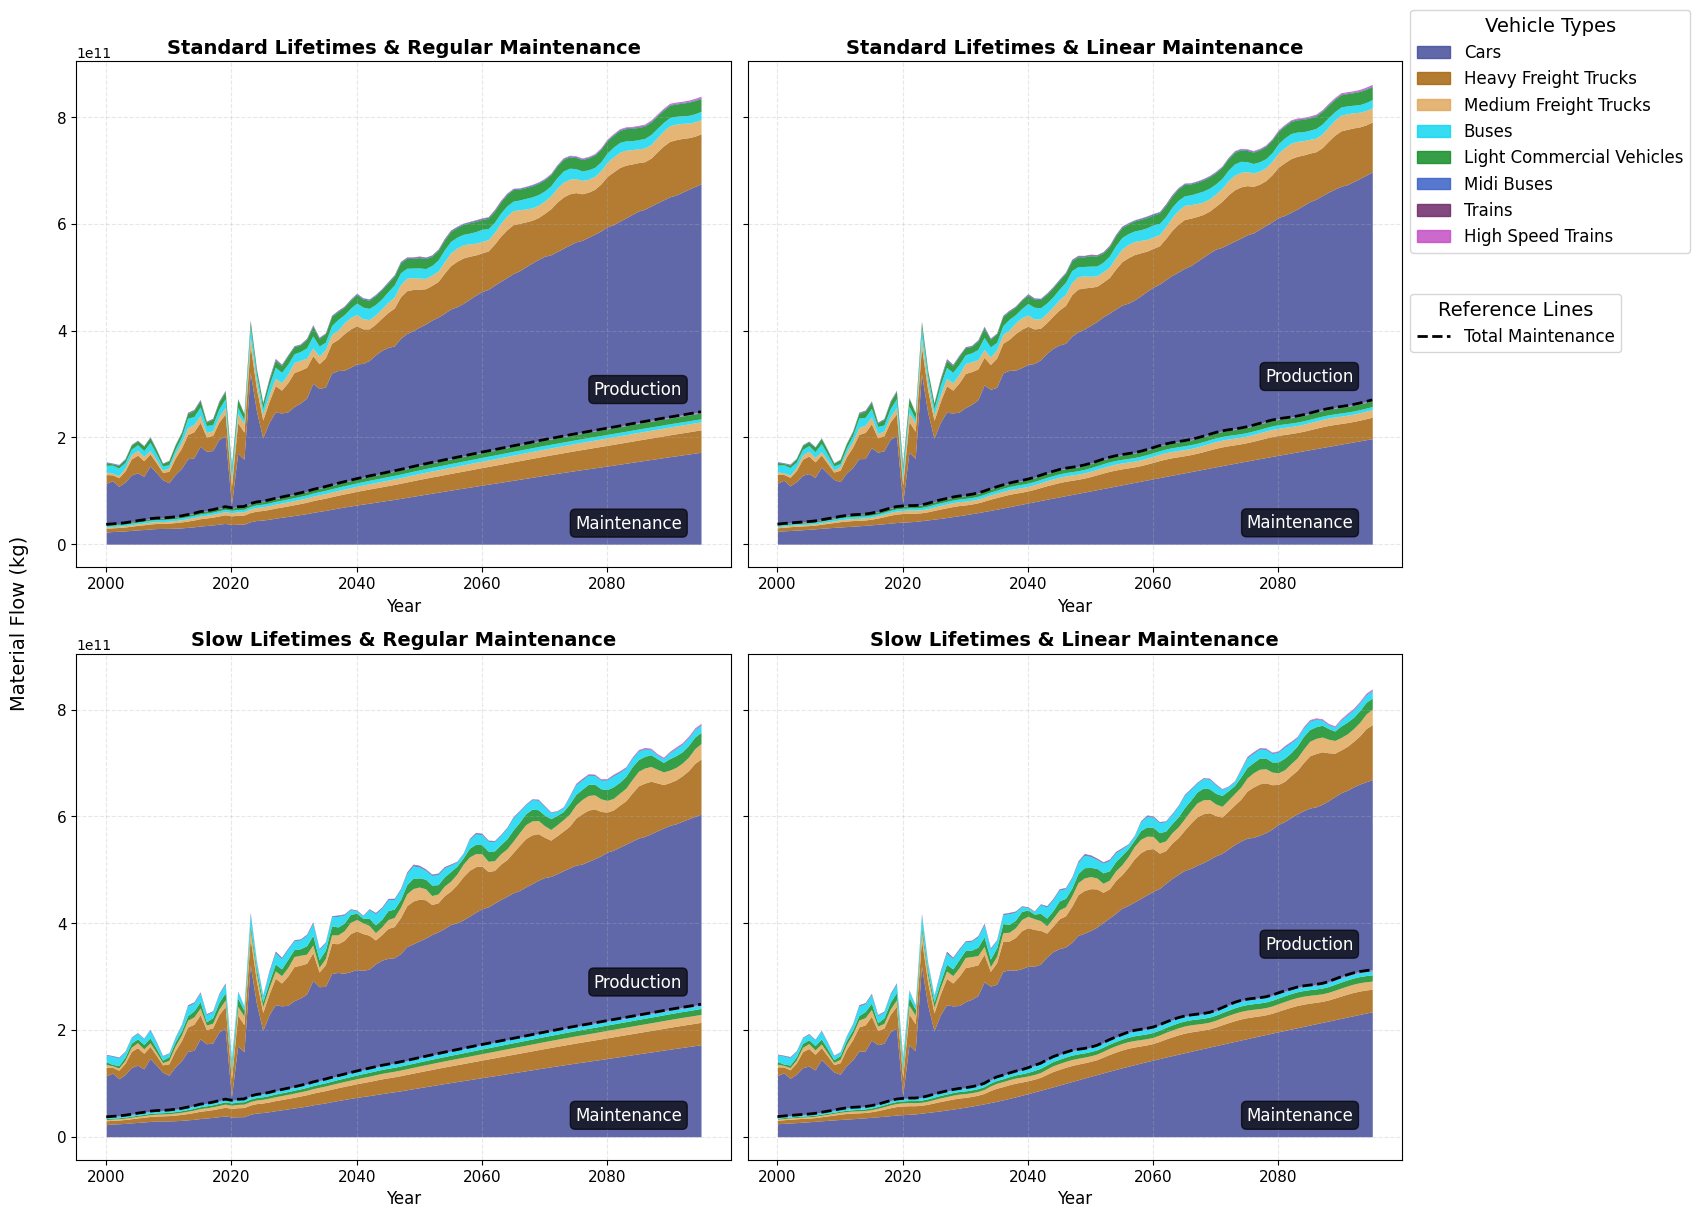

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph

"""
Create 2x2 subplot showing maintenance + production for all four scenarios
with vehicle types stacked and uniform coloring across plots.
"""

# Define vehicle type colors (customize as needed)
type_colors = {
    "Cars": "#444d9b",
    "Light Commercial Vehicles": "#138d27",
    "Regular Buses": "#2ca02c",
    "Midi Buses": "#3b61c7",
    "Trains": "#6e2a69",
    "High Speed Trains": "#c44fc4",
    "Medium Freight Trucks": "#e0a85d",
    "Heavy Freight Trucks": "#a7650f",
    "Trucks": "#bcbd22",
    "Buses": "#12d6f0eb",
}

maintenance_types = [
    "Cars", "Heavy Freight Trucks", "Medium Freight Trucks", "Light Commercial Vehicles", "Buses",
    "Midi Buses", "Trains", "High Speed Trains"
]

# Helper function to process data for each scenario (modified for vehicle types)
def process_scenario_data_by_type(scenario_data):
    # Get maintenance and production data, sum over Region and material (keep Type)
    maint_data = scenario_data['inflow_maintenance']
    prod_data = scenario_data["model"].inflow_materials.to_array()

    # Aggregate by vehicle types and sum over regions and materials
    maint_data = knowledge_graph.aggregate_sum(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'material'])
    prod_data = knowledge_graph.aggregate_sum(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'material'])

    # Convert to pandas DataFrames
    maint_df = maint_data.to_pandas().T
    prod_df = prod_data.to_pandas().T 
    #prod_df = prod_df.rolling(window=5, center=True).mean()
    
    # Process both dataframes
    for df, name in [(maint_df, 'maintenance'), (prod_df, 'production')]:
        if df is None:
            continue
            
        print(f"{name} - Data shape: {df.shape}")
        print(f"{name} - Data columns: {df.columns.tolist()}")
        

        
        # Keep only non-zero vehicle types
        valid_types = (df != 0).any(axis=0)
        df = df.loc[:, valid_types]
    
    # Update the original dataframes
    if prod_df is not None:
        # Ensure both have same columns for consistent plotting
        all_types = set(maint_df.columns) | set(prod_df.columns)
        for vtype in all_types:
            if vtype not in maint_df.columns:
                maint_df[vtype] = 0
            if vtype not in prod_df.columns:
                prod_df[vtype] = 0
        
        # Sort columns by total sum (maintenance + production)
        total_types = maint_df + prod_df
        sorted_cols = total_types.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
        prod_df = prod_df[sorted_cols]
    else:
        # Sort maintenance only
        sorted_cols = maint_df.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
    
    return maint_df, prod_df

# Process all scenarios
processed_data_by_type = {}
for scen_id, scen_data in all_output.items():
    print(f"\nProcessing scenario: {scen_id}")
    maint_df, prod_df = process_scenario_data_by_type(scen_data)
    if not maint_df.empty:
        processed_data_by_type[scen_id] = {'maintenance': maint_df, 'production': prod_df}

# Get all unique vehicle types across scenarios for consistent coloring
all_types = set()
for scen_data in processed_data_by_type.values():
    all_types.update(scen_data['maintenance'].columns)
    if scen_data['production'] is not None:
        all_types.update(scen_data['production'].columns)

# Update type colors to include any missing vehicle types
for vtype in all_types:
    if vtype not in type_colors:
        type_colors[vtype] = '#999999'  # Default gray

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each scenario
scenario_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

for i, scen_id in enumerate(scenario_order):
    ax = axes[i]
    
    if scen_id not in processed_data_by_type:
        ax.text(0.5, 0.5, f"No data for\n{scen_id}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{scen_id} (No Data)", fontsize=14)
        continue
        
    maint_df = processed_data_by_type[scen_id]['maintenance']
    prod_df = processed_data_by_type[scen_id]['production']

    maint_df = maint_df[(maint_df.index >= 2000) & (maint_df.index <= 2095)]
    prod_df = prod_df[(prod_df.index >= 2000) & (prod_df.index <= 2095)]
    
    # Plot maintenance (bottom layer)
    colors_list = [type_colors.get(vtype, '#999999') for vtype in maint_df.columns]
    maint_df.plot.area(
        ax=ax, 
        stacked=True, 
        color=colors_list,
        alpha=0.85, 
        linewidth=0
    )
    ax.get_legend().remove()
    
    # Plot production stacked above maintenance
    if prod_df is not None:
        maintenance_total = maint_df.sum(axis=1)
        prod_bottom = maintenance_total.copy()
        
        for vtype in prod_df.columns:
            if vtype in prod_df.columns and not prod_df[vtype].isna().all():
                top = prod_bottom + prod_df[vtype]
                ax.fill_between(
                    prod_df.index,
                    prod_bottom,
                    top,
                    color=type_colors.get(vtype, '#999999'),
                    alpha=0.85,
                    linewidth=0
                )
                prod_bottom = top
        
        # Plot total maintenance line
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    else:
        # Just maintenance
        maintenance_total = maint_df.sum(axis=1)
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    
    # Styling
    scenario_info = all_output[scen_id]
    title = scenario_info['label']
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    
    # Add labels
    if len(maintenance_total) > 0:
        # Maintenance label
        ax.text(
            maintenance_total.index[-1] - 3,
            ax.get_ylim()[0] + 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "Maintenance",
            color="white", fontsize=12, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )
        
        # Production label (if exists)
        if prod_df is not None:
            ax.text(
                maintenance_total.index[-1] - 3,
                maintenance_total.iloc[-1] * 1.1,
                "Production",
                color="white", fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )

# Add shared Y label
fig.text(-0.02, 0.5, 'Material Flow (kg)', va='center', rotation='vertical', fontsize=14)

# Create shared legend for vehicle types
if processed_data_by_type:
    # Get vehicle types from the first scenario for legend order
    first_scenario = list(processed_data_by_type.values())[0]
    legend_types = first_scenario['maintenance'].columns.tolist()
    
    # Create legend handles
    legend_handles = [mpatches.Rectangle((0,0),1,1, color=type_colors[vtype], alpha=0.85) 
                        for vtype in legend_types]
    
    # Add vehicle types legend
    fig.legend(
        legend_handles, 
        legend_types,
        title="Vehicle Types", 
        bbox_to_anchor=(0.85, 0.91), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    # Add reference line legend
    ref_handles = [plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
    ref_labels = ["Total Maintenance"]
    
    fig.legend(
        ref_handles, 
        ref_labels,
        title="Reference Lines", 
        bbox_to_anchor=(0.85, 0.75), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legends
plt.show()

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\5982758\AppData\Local\Temp\ipykernel_39512\694404328.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

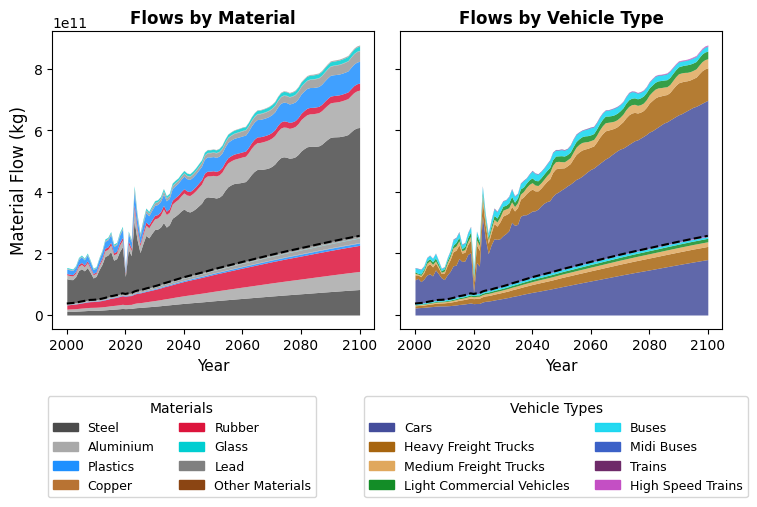

In [90]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph

# --- figure sizing ---
fig_width_inch = 190/25.4   # 190 mm wide
fig_height_inch = 100/25.4  # ~120 mm tall (adjust as needed)

# --- colors ---
type_colors = {
    "Cars": "#444d9b",
    "Light Commercial Vehicles": "#138d27",
    "Regular Buses": "#2ca02c",
    "Midi Buses": "#3b61c7",
    "Trains": "#6e2a69",
    "High Speed Trains": "#c44fc4",
    "Medium Freight Trucks": "#e0a85d",
    "Heavy Freight Trucks": "#a7650f",
    "Trucks": "#bcbd22",
    "Buses": "#12d6f0eb",
}

material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Other Materials": "#8B4513",  # aggregated bucket
}

maintenance_types = [
    "Cars", "Heavy Freight Trucks", "Medium Freight Trucks", "Light Commercial Vehicles",
    "Buses", "Midi Buses", "Trains", "High Speed Trains"
]

# Pick one scenario
scenario_data = all_output["standard_constant"]
maint_data = scenario_data['inflow_maintenance']
prod_data = scenario_data["model"]["inflow_materials"].to_array()

# --- Aggregate by type ---
maint_type = knowledge_graph.aggregate_sum(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region','material']).to_pandas().T
prod_type  = knowledge_graph.aggregate_sum(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region','material']).to_pandas().T

maint_type, prod_type = maint_type[maint_type.index>=2000], prod_type[prod_type.index>=2000]

total_type = maint_type + prod_type
sorted_cols = total_type.sum(axis=0).sort_values(ascending=False).index
maint_type, prod_type = maint_type[sorted_cols], prod_type[sorted_cols]

# --- Aggregate by material ---
maint_mat = knowledge_graph.aggregate_sum(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region','Type']).to_pandas()
prod_mat  = knowledge_graph.aggregate_sum(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region','Type']).to_pandas()

for df in (maint_mat, prod_mat):
    df = df[df.index>=2000]
    cols_to_group = [c for c in ["Other Rare Earths","Cobalt","Wood"] if c in df.columns]
    if cols_to_group:
        df["Other Materials"] = df[cols_to_group].sum(axis=1)
        df.drop(columns=cols_to_group, inplace=True, errors="ignore")
    df.rename(columns={"Pb":"Lead","Co":"Cobalt","Cu":"Copper","Al":"Aluminium"}, inplace=True)

maint_mat, prod_mat = maint_mat[maint_mat.index>=2000], prod_mat[prod_mat.index>=2000]

total_mat = maint_mat + prod_mat
sorted_cols = total_mat.sum(axis=0).sort_values(ascending=False).index
maint_mat, prod_mat = maint_mat[sorted_cols], prod_mat[sorted_cols]

# --- Plot ---
fig, axes = plt.subplots(1,2, figsize=(fig_width_inch, fig_height_inch), sharey=True)

# LEFT: by material
ax = axes[0]
maint_mat.plot.area(ax=ax, stacked=True,
    color=[material_colors.get(m,'#999999') for m in maint_mat.columns],
    alpha=0.85, linewidth=0)
maint_total = maint_mat.sum(axis=1)
prod_bottom = maint_total.copy()
for mat in prod_mat.columns:
    top = prod_bottom + prod_mat[mat]
    ax.fill_between(prod_mat.index, prod_bottom, top,
                    color=material_colors.get(mat,'#999999'), alpha=0.85, linewidth=0)
    prod_bottom = top
ax.plot(maint_total.index, maint_total, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Flows by Material", fontsize=12, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.tick_params(labelsize=10)
ax.legend().set_visible(False)

# RIGHT: by type
ax = axes[1]
maint_type.plot.area(ax=ax, stacked=True,
    color=[type_colors.get(t,'#999999') for t in maint_type.columns],
    alpha=0.85, linewidth=0)
maint_total = maint_type.sum(axis=1)
prod_bottom = maint_total.copy()
for t in prod_type.columns:
    top = prod_bottom + prod_type[t]
    ax.fill_between(prod_type.index, prod_bottom, top,
                    color=type_colors.get(t,'#999999'), alpha=0.85, linewidth=0)
    prod_bottom = top
ax.plot(maint_total.index, maint_total, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Flows by Vehicle Type", fontsize=12, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.tick_params(labelsize=10)
ax.legend().set_visible(False)

# Shared Y label (axis label, not fig.text)
axes[0].set_ylabel("Material Flow (kg)", fontsize=12)

# --- Legends below plots ---
# Order: reverse of stack (top → bottom)
mat_order = mat_order = ["Steel", "Aluminium", "Plastics", "Copper", "Rubber", "Glass", "Lead", "Other Materials"]
type_order = list(maint_type.columns)

mat_handles = [mpatches.Patch(color=material_colors.get(m,'#999999'), label=m) for m in mat_order]
type_handles = [mpatches.Patch(color=type_colors.get(t,'#999999'), label=t) for t in type_order]

# Place a single combined legend row below
all_handles = mat_handles + type_handles
all_labels  = mat_order + type_order

# place them below
fig.legend(handles=mat_handles, loc='upper center', bbox_to_anchor=(0.25,-0.005),
           ncol=2, fontsize=9, title="Materials", title_fontsize=10)
fig.legend(handles=type_handles, loc='upper center', bbox_to_anchor=(0.75,-0.005),
           ncol=2, fontsize=9, title="Vehicle Types", title_fontsize=10)

plt.tight_layout()
plt.subplots_adjust()  # extra space for legend

# save high-res
plt.savefig("flows_material_vs_type.png", dpi=1000, bbox_inches="tight")
plt.show()


In [80]:
type_order

['High Speed Trains',
 'Trains',
 'Midi Buses',
 'Buses',
 'Light Commercial Vehicles',
 'Medium Freight Trucks',
 'Heavy Freight Trucks',
 'Cars']

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Define simulation parameters
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1920, 2100, 1)

scenario_list2 = {
    'slow_linear_capped': {
        'label': 'Slow Lifetimes & Linear Maintenance (Capped)',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear',
        'cap_at_lifetime': True
    },
    'slow_linear_uncapped': {
        'label': 'Slow Lifetimes & Linear Maintenance (Uncapped)',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear',
        'cap_at_lifetime': False
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Constant Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant',
        'cap_at_lifetime': False
    },
    'regular_constant': {
        'label': 'Regular Lifetimes & Constant Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant',
        'cap_at_lifetime': False
    },
}

all_output2 = {}

for scen_id, scenario_config in scenario_list2.items():   
    print(f"\n=== Running Scenario: {scen_id} ===")
    
    # Select the appropriate sector data based on circular economy scenario
    if scenario_config['circular_scen'] == 'standard':
        sector_data = vhc_sector
        if scenario_config["cap_at_lifetime"]==True:
            sector_data.all_data["cap_at_lifetime"]=True
            print("Capping maintenance at lifetime")
        else:
            sector_data.all_data["cap_at_lifetime"]=False
            print("Not capping maintenance at lifetime")
        print("Using standard sector data")
    elif scenario_config['circular_scen'] == 'slow':
        sector_data = vhc_sector_slow
        if scenario_config["cap_at_lifetime"]==True:
            sector_data.all_data["cap_at_lifetime"]=True
            print("Capping maintenance at lifetime")
        else:
            sector_data.all_data["cap_at_lifetime"]=False
            print("Not capping maintenance at lifetime")
        print("Using slow circular economy sector data")
    
    # Create factory with appropriate sector data
    factory = ModelFactory(
        sector_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials)
    
    # Add the appropriate maintenance model based on maintenance scenario
    if scenario_config['maintenance_scen'] == 'constant':
        factory = factory.add(Maintenance)
        print("Using constant maintenance model")
    elif scenario_config['maintenance_scen'] == 'linear':
        if 'cap_at_lifetime' in scenario_config:
            MaintenanceLinear.cap_at_lifetime = scenario_config['cap_at_lifetime']
            cap_status = "capped" if scenario_config['cap_at_lifetime'] else "uncapped"
            print(f"Using linear maintenance model ({cap_status} at lifetime)")
        
        # Add the original class (now with modified attribute)
        factory = factory.add(MaintenanceLinear)
        
    
    # Finish model creation
    model = factory.finish()
    
    # Run simulation
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)
    
    # Store results
    all_output2[scen_id] = {
        'model': model,
        'inflow_maintenance': model.inflow_maintenance.to_array(),
        'circular_scenario': scenario_config['circular_scen'],
        'maintenance_scenario': scenario_config['maintenance_scen'],
        'cap_at_lifetime': scenario_config["cap_at_lifetime"],  # Default is True
        'label': scenario_config['label']
    }
    


print(f"\n=== All {len(all_output2)} scenarios completed successfully ===")
print("Available scenarios:", list(all_output2.keys()))


=== Running Scenario: slow_linear_capped ===
Capping maintenance at lifetime
Using slow circular economy sector data
Using linear maintenance model (capped at lifetime)
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model (capped at lifetime)
Initialized MaintenanceLinear with 47 maintenance types
2100
=== Running Scenario: slow_linear_uncapped ===
Not capping maintenance at lifetime
Using slow circular economy sector data

=== Running Scenario: slow_linear_uncapped ===
Not capping maintenance at lifetime
Using slow circular economy sector data
Using linear maintenance model (uncapped at lifetime)
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model (uncapped at lifetime)
Initialized MaintenanceLinear with 47 maintenance types
2100
=== Running Scenario: slow_constant ===
Not capping maintenance at lifetime
Using slow circular economy sector data

=== Running Scenario: slow_constant ===
Not capping maintenance at lifet

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of 

Slow Lifetimes & Linear Maintenance (Capped): Total maintenance 2020-2100: 1.46e+13 kg
Slow Lifetimes & Linear Maintenance (Uncapped): Total maintenance 2020-2100: 1.62e+13 kg
Slow Lifetimes & Constant Maintenance: Total maintenance 2020-2100: 1.36e+13 kg
Regular Lifetimes & Constant Maintenance: Total maintenance 2020-2100: 1.36e+13 kg


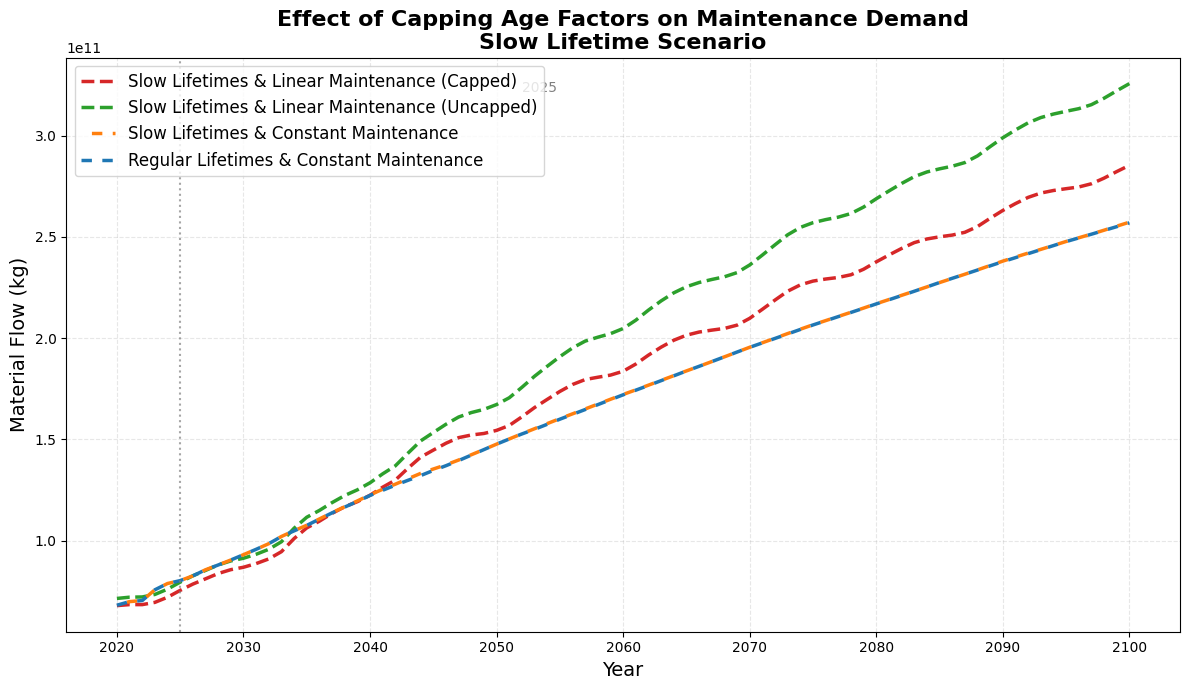

In [61]:
def plot_capping_comparison(all_output, year_range=(2020, 2100)):
    """
    Create a comparison plot of maintenance demand between capped and uncapped age factors
    for slow linear scenarios.
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Define colors
    colors = {
        'slow_linear_capped': '#d62728',    # greend62728
        'slow_linear_uncapped': '#2ca02c',  # red
        "regular_constant": '#1f77b4',  # blue
        "slow_constant": '#ff7f0e',  # orange
    }
    
    # Define line styles
    line_styles = {
        'slow_linear_capped': '--',    
        'slow_linear_uncapped': '--',  
        "regular_constant": (0, (3, 3)),  
        "slow_constant": (3, (3, 3)), 
    }
    
    legend_entries = []
    
    # Plot data for selected scenarios
    for scenario_id in ['slow_linear_capped', 'slow_linear_uncapped',"slow_constant","regular_constant"]:
        if scenario_id not in all_output:
            print(f"Warning: Scenario {scenario_id} not found!")
            continue
            
        scenario_data = all_output[scenario_id]
        label = scenario_data['label']
        
        # Get maintenance data
        maint_array = scenario_data['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_df = maint_df[(maint_df.index >= year_range[0]) & (maint_df.index <= year_range[1])]
        
        # Plot the line
        line, = ax.plot(maint_df.index, maint_df, 
                        label=label,
                        color=colors.get(scenario_id, '#999999'),
                        linestyle=line_styles.get(scenario_id, '-'),
                        linewidth=2.5)
        
        legend_entries.append(line)
        
        # Calculate total maintenance (sum)
        total_maint = maint_df.sum()
        print(f"{label}: Total maintenance {year_range[0]}-{year_range[1]}: {total_maint:.2e} kg")
    
    # Calculate and display percentage difference
    if 'slow_linear_capped' in all_output and 'slow_linear_uncapped' in all_output:
        capped_total = all_output['slow_linear_capped']['inflow_maintenance'].sel(time=slice(2025,2100)).sum(
            dim=['Region', 'Type', 'material', 'time']).values
        uncapped_total = all_output['slow_linear_uncapped']['inflow_maintenance'].sel(time=slice(2025,2100)).sum(
            dim=['Region', 'Type', 'material', 'time']).values
        standard_total = all_output['slow_constant']['inflow_maintenance'].sel(time=slice(2025,2100)).sum(
            dim=['Region', 'Type', 'material', 'time']).values
        
        # Calculate differences from standard scenario
        diff_standard_to_capped = capped_total - standard_total
        diff_standard_to_uncapped = uncapped_total - standard_total
        
        # Calculate percentage differences
        pct_diff_capped = ((capped_total - standard_total) / standard_total) * 100
        pct_diff_uncapped = ((uncapped_total - standard_total) / standard_total) * 100
        
        # Add annotation about differences from standard
        text = f"Differences vs Standard Constant (2025-2100):\n"
        text += f"Capped: {pct_diff_capped:+.1f}% ({diff_standard_to_capped:+.2e} kg)\n"
        text += f"Uncapped: {pct_diff_uncapped:+.1f}% ({diff_standard_to_uncapped:+.2e} kg)"
        
        #ax.text(0.05, 0.6, text, 
        #        transform=ax.transAxes, 
        #        fontsize=12, 
        #        verticalalignment='top',
        #        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add vertical line at 2050 for reference
    ax.axvline(x=2025, color='gray', linestyle=':', alpha=0.7)
    ax.text(2052, ax.get_ylim()[1]*0.95, '2025', color='gray')
    
    # Styling
    ax.set_title('Effect of Capping Age Factors on Maintenance Demand\nSlow Lifetime Scenario', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Material Flow (kg)', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(handles=legend_entries, loc='upper left', fontsize=12)
    
    # Format y-axis with scientific notation
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    plt.tight_layout()
    plt.savefig('Figure5_2.png', dpi=1000, bbox_inches='tight')
    plt.show()
    


# Call the function
comparison_results = plot_capping_comparison(all_output2)


KeyError: 'production'

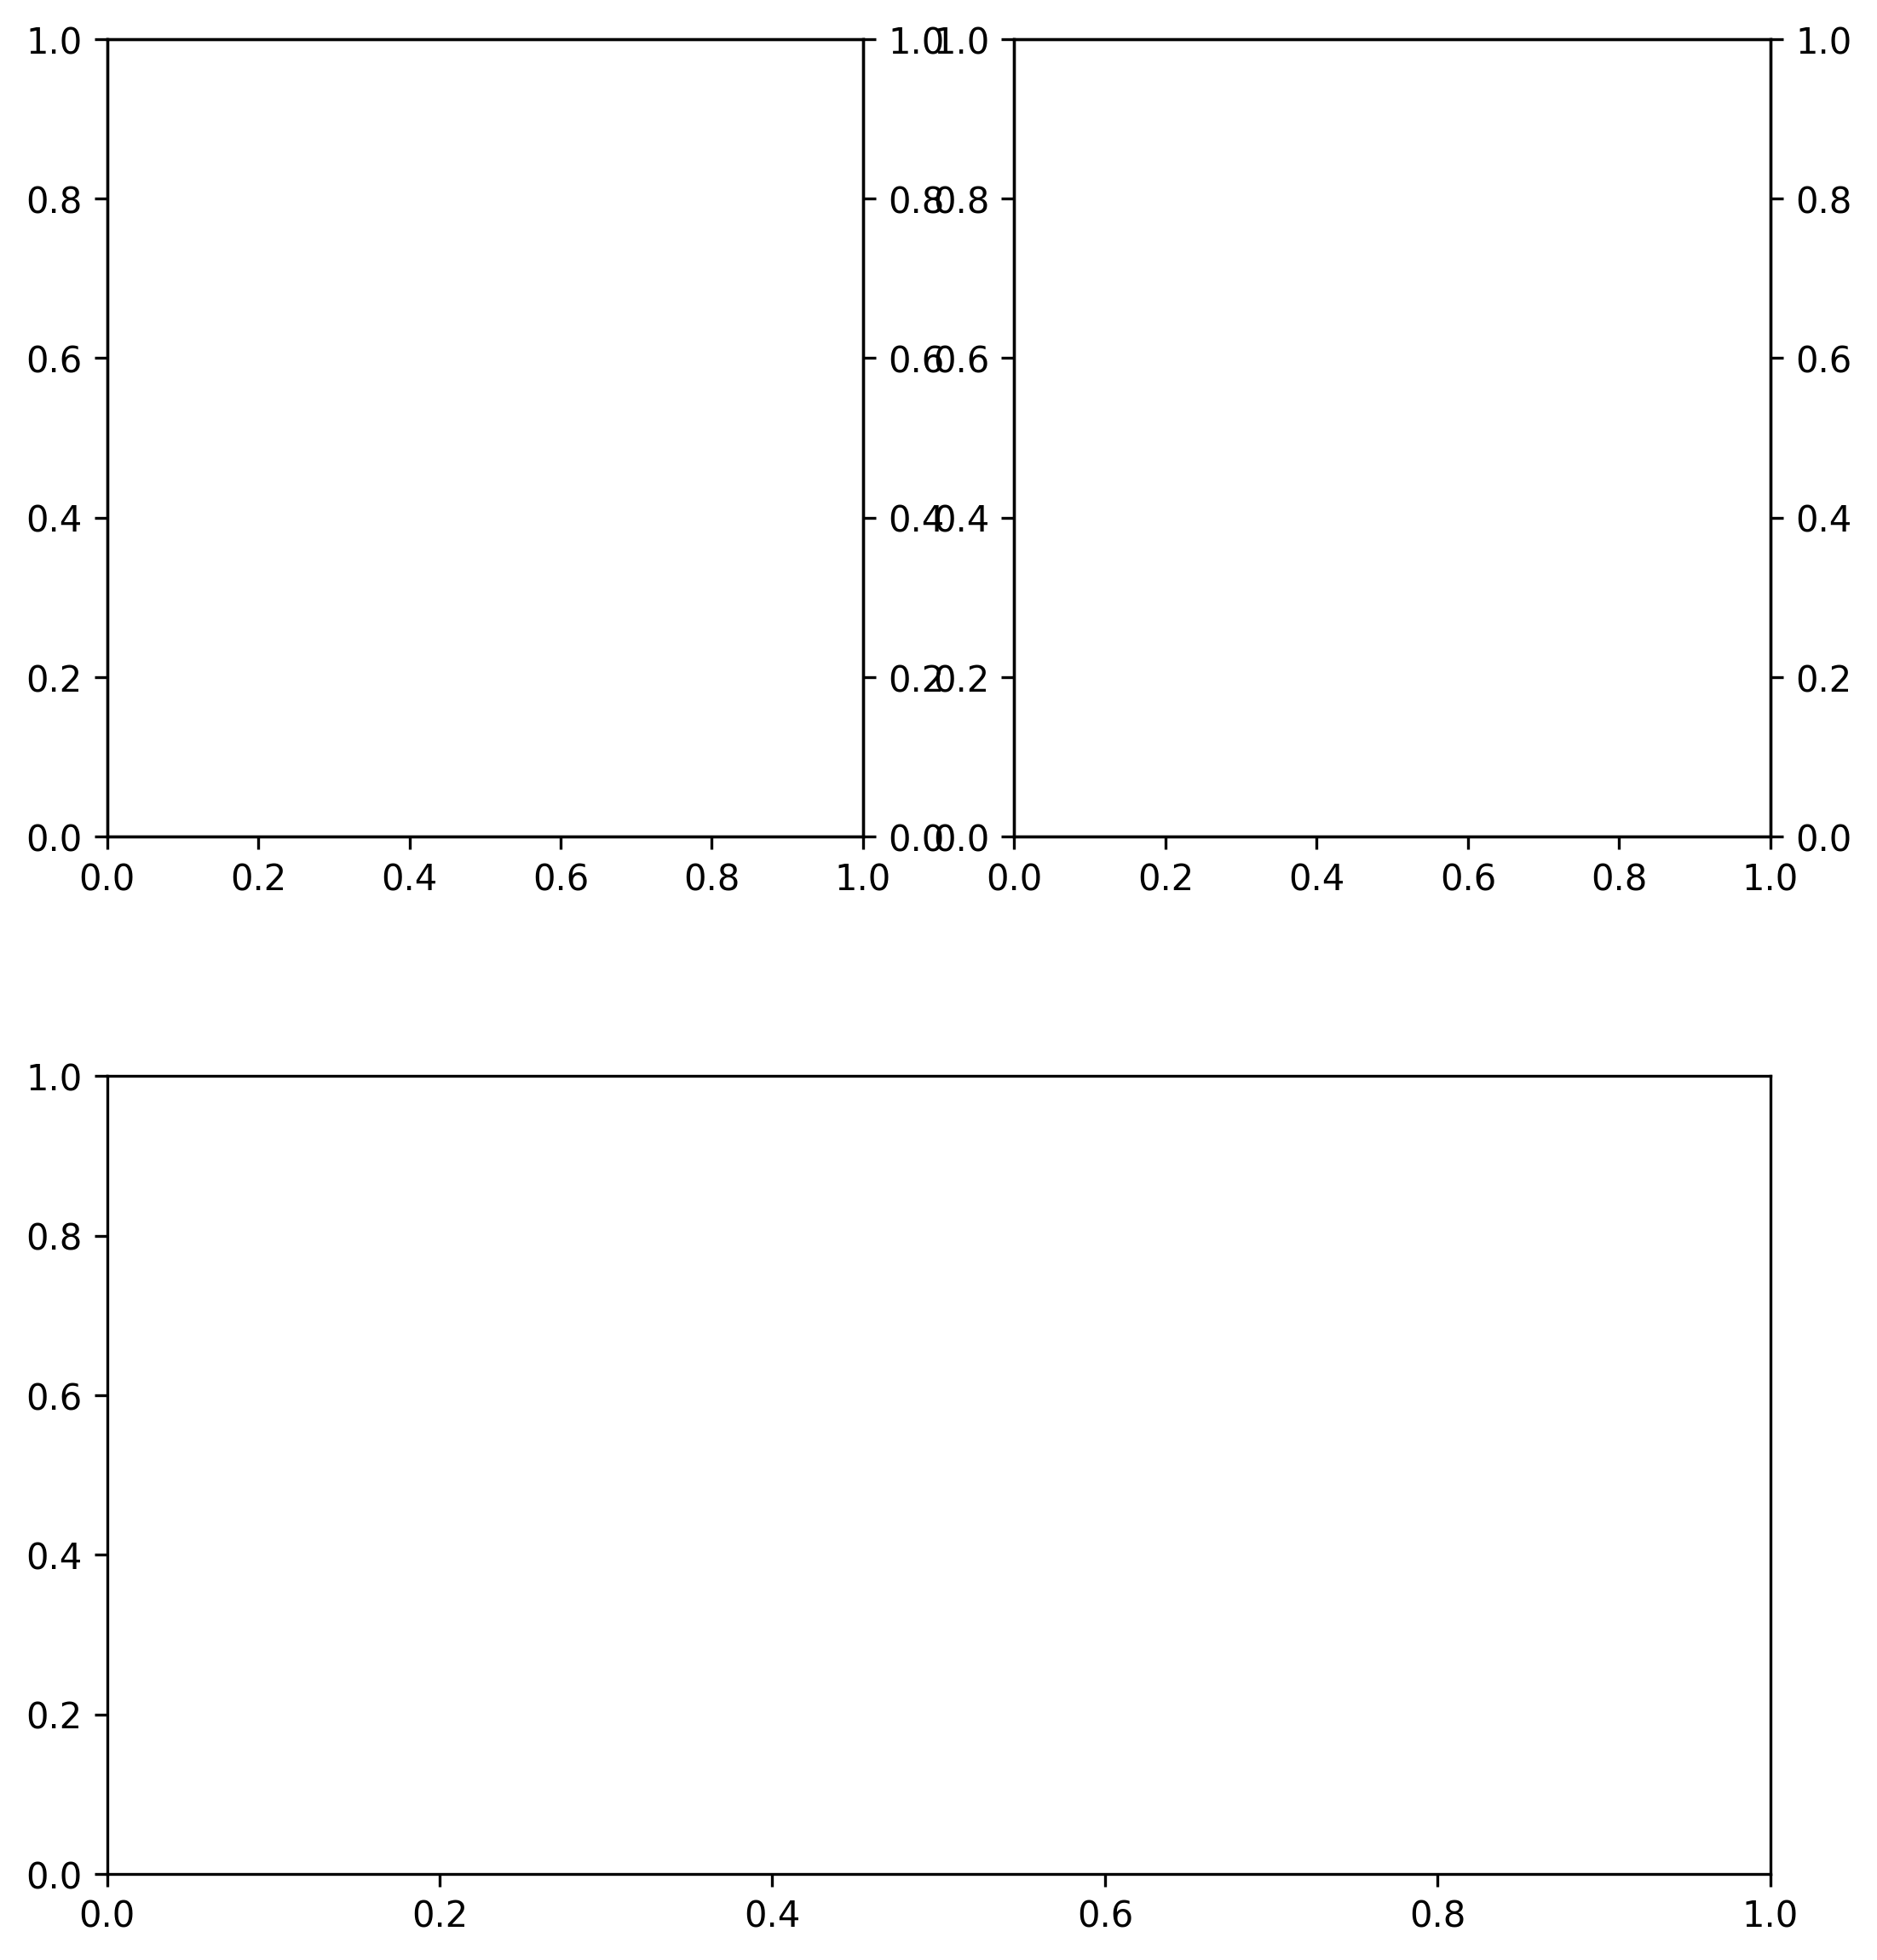

In [52]:

# Set up figure dimensions for publication (190mm width, 1000 DPI)
width_mm = 190
width_inches = width_mm / 25.4  # Convert mm to inches
height_inches = width_inches * 1.2  # Adjust height ratio as needed

fig = plt.figure(figsize=(width_inches, height_inches), dpi=300)  # Use 300 DPI for display

# Create grid layout: 2 plots on top, 1 plot on bottom
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.2, 
                        left=0.08, right=0.95, top=0.95, bottom=0.15)

# Top left: Production comparison
ax1 = fig.add_subplot(gs[0, 0])
ax1_pct = ax1.twinx()

# Top right: Maintenance comparison  
ax2 = fig.add_subplot(gs[0, 1])
ax2_pct = ax2.twinx()

# Bottom: Capping comparison (spanning both columns)
ax3 = fig.add_subplot(gs[1, :])

# ===== TOP PLOTS: Production and Maintenance Comparison =====

# Define scenarios and data
scenarios = ['slow_linear', 'standard_linear']
scenario_colors = {'slow_linear': '#1f77b4', 'standard_linear': '#ff7f0e'}

comparison_types = ['Production', 'Maintenance']
axes = [ax1, ax2]
pct_axes = [ax1_pct, ax2_pct]

for idx, comp_type in enumerate(comparison_types):
    ax = axes[idx]
    ax_pct = pct_axes[idx]
    
    # Get baseline (slow_linear) data
    baseline_key = 'production' if comp_type == 'Production' else 'maintenance'
    baseline_data = knowledge_graph.aggregate_sum(
        all_output['slow_linear'][baseline_key], 
        'material', year_range=(2020, 2100)
    )
    baseline_df = baseline_data.to_pandas()
    
    # Plot scenarios
    for scenario in scenarios:
        data = knowledge_graph.aggregate_sum(
            all_output[scenario][baseline_key], 
            'material', year_range=(2020, 2100)
        )
        df = data.to_pandas()
        
        color = scenario_colors[scenario]
        label = 'Slow linear' if scenario == 'slow_linear' else 'Standard linear'
        
        ax.plot(df.index, df.values / 1e9, color=color, linewidth=2, label=label)
    
    # Calculate and plot percentage difference
    standard_data = knowledge_graph.aggregate_sum(
        all_output['standard_linear'][baseline_key], 
        'material', year_range=(2020, 2100)
    )
    standard_df = standard_data.to_pandas()
    
    pct_diff = ((standard_df - baseline_df) / baseline_df * 100)
    ax_pct.plot(pct_diff.index, pct_diff.values, 
                color='red', linestyle='--', linewidth=1.5, alpha=0.8,
                label='% difference')
    
    # Formatting
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(f'{comp_type} (Gt)', fontsize=10)
    ax_pct.set_ylabel('% difference', fontsize=10, color='red')
    ax_pct.tick_params(axis='y', labelcolor='red')
    
    ax.tick_params(labelsize=9)
    ax_pct.tick_params(labelsize=9)
    ax.grid(True, alpha=0.3)
    
    # Set title
    ax.set_title(f'{comp_type} Comparison', fontsize=11, fontweight='bold')

# ===== BOTTOM PLOT: Capping Comparison =====

# Capped vs uncapped maintenance data
capped_data = knowledge_graph.aggregate_sum(
    all_output['slow_linear_capped']['maintenance'], 
    'material', year_range=(2020, 2100)
)
uncapped_data = knowledge_graph.aggregate_sum(
    all_output['slow_linear_uncapped']['maintenance'], 
    'material', year_range=(2020, 2100)
)

capped_df = capped_data.to_pandas()
uncapped_df = uncapped_data.to_pandas()

# Plot both scenarios
ax3.plot(capped_df.index, capped_df.values / 1e9, 
        color='#2ca02c', linewidth=2, label='Capped')
ax3.plot(uncapped_df.index, uncapped_df.values / 1e9, 
        color='#d62728', linewidth=2, label='Uncapped')

# Calculate percentage difference
pct_diff = ((capped_df - uncapped_df) / uncapped_df * 100)
ax3_pct = ax3.twinx()
ax3_pct.plot(pct_diff.index, pct_diff.values, 
            color='purple', linestyle='--', linewidth=1.5, alpha=0.8,
            label='% difference')

# Formatting for bottom plot
ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('Maintenance (Gt)', fontsize=10)
ax3_pct.set_ylabel('% difference', fontsize=10, color='purple')
ax3_pct.tick_params(axis='y', labelcolor='purple')

ax3.tick_params(labelsize=9)
ax3_pct.tick_params(labelsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_title('Maintenance: Capped vs Uncapped', fontsize=11, fontweight='bold')

# ===== SHARED LEGEND =====

# Collect all legend elements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines3_pct, labels3_pct = ax3_pct.get_legend_handles_labels()

# Combine all legend elements
all_lines = lines1 + lines3 + lines3_pct
all_labels = labels1 + labels3 + labels3_pct

# Create shared legend at bottom
fig.legend(all_lines, all_labels, loc='lower center', 
            bbox_to_anchor=(0.5, 0.02), ncol=len(all_lines), 
            fontsize=9, frameon=True)

plt.tight_layout()

# Save with high DPI for publication
plt.savefig('combined_maintenance_production_analysis.png', 
            dpi=1000, bbox_inches='tight', facecolor='white')
plt.show()



Creating horizontal combined figure...

Creating vertical combined figure...
Combined figure saved as: Figure2_combined_vertical.png


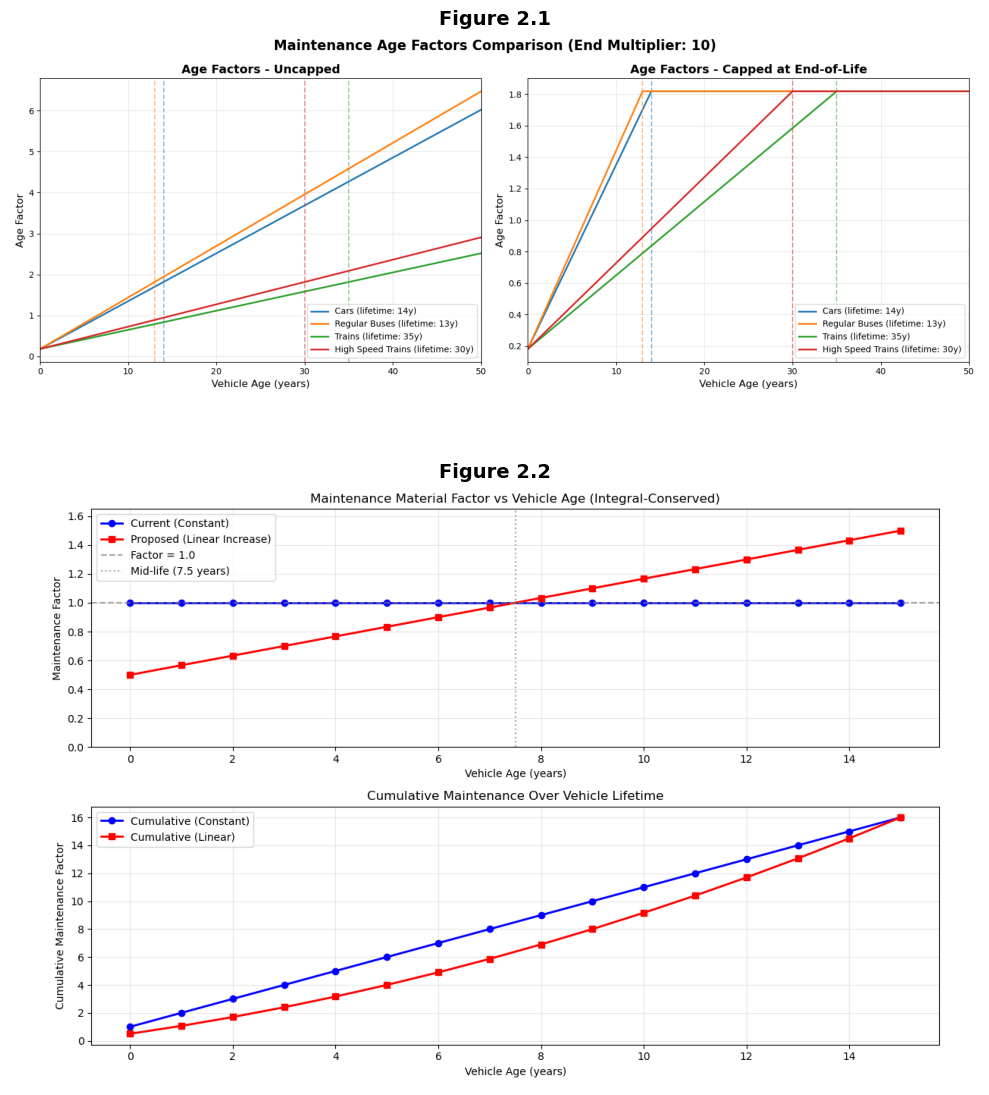

In [92]:
# Merge Figure5_1.png and Figure5_2.png into a single figure
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

def merge_figures():
    """Merge Figure5_1.png and Figure5_2.png into a single combined figure"""
    
    # Define file paths
    fig1_path = Path('Figure2_bottom.png')
    fig2_path = Path('Figure2_top.png')
    
    # Load the images
    img1 = mpimg.imread(fig1_path)
    img2 = mpimg.imread(fig2_path)
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Display images
    ax1.imshow(img1)
    ax1.set_title('Figure 2.1', fontsize=14, fontweight='bold')
    ax1.axis('off')  # Remove axes
    
    ax2.imshow(img2)
    ax2.set_title('Figure 2.2', fontsize=14, fontweight='bold')
    ax2.axis('off')  # Remove axes
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the combined figure
    output_path = 'Figure2_combined.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Combined figure saved as: {output_path}")
    
    plt.show()

# Alternative vertical layout function
def merge_figures_vertical():
    """Merge Figure5_1.png and Figure5_2.png vertically"""
    
    # Define file paths
    fig1_path = Path('Figure2_bottom.png')
    fig2_path = Path('Figure2_top.png')
    
    
    # Load the images
    img1 = mpimg.imread(fig1_path)
    img2 = mpimg.imread(fig2_path)
    
    # Create figure with vertical subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    
    # Display images
    ax1.imshow(img1)
    ax1.set_title('Figure 2.1', fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    ax2.imshow(img2)
    ax2.set_title('Figure 2.2', fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the combined figure
    output_path = 'Figure2_combined_vertical.png'
    plt.savefig(output_path, dpi=1000, bbox_inches='tight', facecolor='white')
    print(f"Combined figure saved as: {output_path}")
    
    plt.show()

# Run horizontal merge (side by side)
print("Creating horizontal combined figure...")
#merge_figures()

print("\nCreating vertical combined figure...")
merge_figures_vertical()